# High Risk Project — AI in Healthcare

## Auditing Local LLM Workflows for Older-Adult Referral Support

**Course:** AI in Healthcare, MSAI, UT Austin  
**Project type:** High Risk Project / research prototype  
**Data source:** MIMIC-IV-Ext-CDS v1.0.2  
**Study population:** Older adults aged 65 years and older  
**Notebook role:** End-to-end experimental and reproducibility notebook  
**Primary workflow types:** Classical baselines + local LLM audit workflows  
**LLM setting:** Local inference using Qwen / Phi family models  
**Research framing:** Audit-style evaluation, not a clinical deployment system  

## Study scope

This notebook implements an **audit-style evaluation framework** for **older-adult intake-stage specialist referral support** using structured and semi-structured case-level data derived from **MIMIC-IV-Ext-CDS v1.0.2**.

The notebook is designed to support a graduate-level **High Risk Project** by combining:

1. **Classical baseline benchmarking**
   - Majority-label baseline  
   - TF-IDF + Logistic Regression baseline  

2. **Local LLM workflow evaluation**
   - Raw intake-text prompting  
   - Standardized geriatric-profile prompting  
   - Within-case evidence-attributed prompting  
   - Abstention-aware prompting  

3. **Robustness and sensitivity analysis**
   - Local model sensitivity across selected Qwen / Phi models  
   - Persona-conditioned communication stress testing  
   - Analysis of caregiver-mediated, poor-recall, mild-confusion, and fall-underreporting scenarios  

4. **Evaluation and audit outputs**
   - Accuracy  
   - Macro-F1  
   - Top-3 recall  
   - Parse success  
   - Citation-ID validity  
   - Abstention / coverage behavior  
   - Selective accuracy  
   - Persona degradation analysis  
   - Bootstrap confidence intervals  

## Main research questions

This notebook evaluates the following practical research questions:

1. How do local LLM referral-support workflows compare with classical baselines for older-adult specialist referral prediction?
2. Does standardized geriatric-profile representation improve structured prediction performance or robustness?
3. Does within-case evidence attribution improve traceability, even if it does not improve classification performance?
4. How stable are local LLM workflows under communication perturbations that are relevant to older-adult care?
5. Do caregiver-mediated or degraded subjective-intake scenarios reveal important fragility for future healthcare AI systems?

## Important interpretation note

This notebook should be interpreted as a **research and auditing framework**, not as a clinical decision tool.

- The goal is **not** to claim clinical deployment readiness.
- Citation-ID validity does **not** prove clinical correctness or rationale faithfulness.
- Communication stress testing is a **deterministic experimental probe**, not a validated simulation of real patient behavior.
- Any implications for **health data platforms** or **super-aging healthcare systems** should be treated as **motivated future directions**, not as proven causal conclusions.

## Expected outcome

The scientific value of this notebook is not limited to whether local LLMs outperform classical baselines.  
It also supports a broader evaluation of:

- performance patterns,
- evidence traceability,
- failure modes,
- model sensitivity,
- abstention behavior,
- and fragility under older-adult communication stress.


## Section 0 — Important usage notes

### Primary benchmark
This notebook assumes that you have access to the MIMIC-IV-Ext-CDS v1.0.2 official CSV bundle or to a previously merged case-level file generated from that bundle.

### Implementation note

This notebook keeps the core older-adult referral-support experiment intact while making model comparisons safer and more isolated.

Main implementation choices:
1. The primary Qwen2.5-1.5B workflow remains the full core experiment.
2. Qwen2.5-3B is evaluated in a clean-condition model-sensitivity track.
3. Phi-4-mini is executed through an isolated subprocess with row-level checkpointing.
4. Dependency checks are included for the Phi-4-mini execution path.
5. Fresh cache tags are used to reduce the risk of stale artifacts.

### Recommended execution pattern
1. Run the installation cell.
2. Restart the Colab runtime.
3. Run the notebook from the top.
4. Let the main Qwen sensitivity section complete.
5. Run the isolated Phi-4-mini section. If Phi fails, the already completed Qwen results remain safe in Drive.

### Interpretation rule
If Phi-4-mini still fails after the isolated run, report it transparently as an implementation/runtime limitation rather than hiding it. The Qwen2.5-1.5B vs Qwen2.5-3B scaling comparison remains scientifically useful.

**v1.10 sanity fix:** `INPUT_BOUNDARY_MODE` is defined in the global configuration cell before `RUN_TAG` is created to avoid fresh-runtime `NameError`.

In [2]:
# =========================================================
# 1. Install packages
# =========================================================
# v1.10 note:
# Phi-4-mini is version-sensitive. The official model card lists
# transformers==4.49.0 and accelerate==1.3.0 for Transformers inference.
# After running this cell in Colab, restart the runtime before continuing.

!pip -q install -U pandas pyarrow scikit-learn matplotlib seaborn joblib tqdm \
                 sentence-transformers datasets rank-bm25 google-cloud-bigquery \
                 db-dtypes rapidfuzz safetensors huggingface_hub

!pip -q install --no-cache-dir --upgrade \
                 "transformers==4.49.0" \
                 "accelerate==1.3.0" \
                 "bitsandbytes>=0.43.3"

print("Install completed.")
print("IMPORTANT: In Colab, restart the runtime now: Runtime > Restart session/runtime, then run from the top again.")


Install completed.
IMPORTANT: In Colab, restart the runtime now: Runtime > Restart session/runtime, then run from the top again.


In [3]:
# =========================================================
# 2. Imports and reproducibility
# =========================================================

import os
import re
import gc
import json
import math
import time
import random
import hashlib
import warnings
from pathlib import Path
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from rapidfuzz import process, fuzz

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_SEED = 42

def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_all_seeds(RANDOM_SEED)
print("Seed fixed:", RANDOM_SEED)

Seed fixed: 42


In [4]:
# =========================================================
# 3. Google Drive mount and project directories
# =========================================================

from google.colab import drive
drive.mount("/content/drive")

PROJECT_TITLE = "Auditing Local LLM Workflows for Older-Adult Referral Support: Evidence Attribution, Model Sensitivity, Communication Stress Testing, and Data-Platform Implications"
PROJECT_VERSION = "v1_10"

PROJECT_ROOT = "/content/drive/MyDrive/msai_high_risk_project"
DATA_RAW_DIR = f"{PROJECT_ROOT}/data_raw"
DATA_PROCESSED_DIR = f"{PROJECT_ROOT}/data_processed"
PROFILES_DIR = f"{PROJECT_ROOT}/profiles"
RETRIEVAL_DIR = f"{PROJECT_ROOT}/retrieval_cache"
PREDICTIONS_DIR = f"{PROJECT_ROOT}/predictions"
METRICS_DIR = f"{PROJECT_ROOT}/metrics"
PLOTS_DIR = f"{PROJECT_ROOT}/plots"
AUDIT_DIR = f"{PROJECT_ROOT}/audit"
CONFIG_DIR = f"{PROJECT_ROOT}/configs"

for p in [
    PROJECT_ROOT, DATA_RAW_DIR, DATA_PROCESSED_DIR, PROFILES_DIR,
    RETRIEVAL_DIR, PREDICTIONS_DIR, METRICS_DIR, PLOTS_DIR,
    AUDIT_DIR, CONFIG_DIR
]:
    Path(p).mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Mounted at /content/drive
Project root: /content/drive/MyDrive/msai_high_risk_project


In [5]:
# =========================================================
# 4. Global study configuration
# =========================================================

# -------------------------
# Execution toggles
# -------------------------
USE_BIGQUERY_ENRICHMENT = False
RUN_LLM_EXPERIMENTS = True
RUN_ABSTENTION_ARM = True
RUN_PERSONA_STRESS_TEST = True

# -------------------------
# Official PhysioNet raw files
# You download these manually into EXTCDS_OFFICIAL_DIR.
# The notebook can auto-build one merged case-level CSV from them.
# -------------------------
EXTCDS_OFFICIAL_DIR = f"{DATA_RAW_DIR}/mimic_iv_ext_cds_1_0_2"
AUTO_BUILD_EXTCDS_CASES = True
WRITE_MERGED_CASES_CSV = True
USE_CLINICIAN_APPROVED_REFERRALS = False   # True = restrict to clinician-approved subset if file exists

# -------------------------
# Main benchmark file used by the rest of the notebook
# This file will be auto-created from the official CSV bundle if needed.
# -------------------------
EXTCDS_CASES_PATH = f"{DATA_RAW_DIR}/mimic_iv_ext_cds_cases.csv"

# -------------------------
# BigQuery configuration
# -------------------------
GCP_PROJECT_ID = "YOUR_GCP_PROJECT_ID"     # replace if using BigQuery
SCRATCH_DATASET = "msai_scratch"           # replace if using BigQuery
SCRATCH_TABLE = "extcds_case_ids"

BQ_SOURCE_PROJECT = "physionet-data"
BQ_HOSP_DATASET = "mimiciv_v3_1_hosp"

# -------------------------
# Column override mapping
# If auto-detection fails, set values below
# -------------------------
COLUMN_MAP_OVERRIDE = {
    "case_id": None,
    "subject_id": None,
    "hadm_id": None,
    "age": None,
    "sex": None,
    "referral_label": None,
    "triage_label": None,
    "chief_complaint": None,
    "hpi": None,
    "pmh": None,
    "vitals": None,
    "labs": None,
    "medications": None,
    "assessment": None,
    "plan": None,
}

# -------------------------
# Study scope
# -------------------------
MIN_AGE = 65
TOP_K_REFERRAL_LABELS = 8
LLM_SAMPLE_SIZE = 200
N_MANUAL_AUDIT = 40
TOP_K_EVIDENCE = 4

# -------------------------
# Input boundary / information scope
# -------------------------
# INTAKE = use only intake-stage information for referral prediction.
# This must be defined before RUN_TAG so fresh Colab runtimes are reproducible.
INPUT_BOUNDARY_MODE = "INTAKE"

# -------------------------
# Local LLM config
# -------------------------
LOCAL_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
MAX_NEW_TOKENS = 220
TEMPERATURE = 0.0
DO_SAMPLE = False

# -------------------------
# Retrieval / embedding config
# -------------------------
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# -------------------------
# Persona stress-test config
# -------------------------
PERSONA_TYPES = [
    "poor_recall",
    "mild_confusion",
    "caregiver_mediated",
    "fall_underreport",
]

# --- FIX: Dynamically track versions to prevent stale caches ---
# Set to v1.10 to ensure a completely fresh run without overwriting or reading previous cached generations.
BASELINE_CACHE_VERSION = "v1_10"
RUN_TAG = f"{BASELINE_CACHE_VERSION}_seed{RANDOM_SEED}_top{TOP_K_REFERRAL_LABELS}_{INPUT_BOUNDARY_MODE}_{LOCAL_MODEL_NAME.split('/')[-1]}"

config_dump = {
    "project_title": PROJECT_TITLE,
    "project_version": PROJECT_VERSION,
    "baseline_cache_version": BASELINE_CACHE_VERSION,
    "run_tag": RUN_TAG,
    "random_seed": RANDOM_SEED,
    "min_age": MIN_AGE,
    "top_k_referral_labels": TOP_K_REFERRAL_LABELS,
    "llm_sample_size": LLM_SAMPLE_SIZE,
    "top_k_evidence": TOP_K_EVIDENCE,
    "local_model_name": LOCAL_MODEL_NAME,
    "embedding_model_name": EMBEDDING_MODEL_NAME,
    "persona_types": PERSONA_TYPES,
    "extcds_official_dir": EXTCDS_OFFICIAL_DIR,
    "auto_build_extcds_cases": AUTO_BUILD_EXTCDS_CASES,
    "write_merged_cases_csv": WRITE_MERGED_CASES_CSV,
    "use_clinician_approved_referrals": USE_CLINICIAN_APPROVED_REFERRALS,
    "extcds_cases_path": EXTCDS_CASES_PATH,
}

with open(f"{CONFIG_DIR}/config.json", "w") as f:
    json.dump(config_dump, f, indent=2)

config_dump


{'project_title': 'Auditable Clinical Referral Agents for Super-Aging Populations: A Persona-Driven Stress Test of Evidence-Grounded LLMs',
 'project_version': 'v1_10',
 'baseline_cache_version': 'v1_10',
 'run_tag': 'v1_10_seed42_top8_INTAKE_Qwen2.5-1.5B-Instruct',
 'random_seed': 42,
 'min_age': 65,
 'top_k_referral_labels': 8,
 'llm_sample_size': 200,
 'top_k_evidence': 4,
 'local_model_name': 'Qwen/Qwen2.5-1.5B-Instruct',
 'embedding_model_name': 'sentence-transformers/all-MiniLM-L6-v2',
 'persona_types': ['poor_recall',
  'mild_confusion',
  'caregiver_mediated',
  'fall_underreport'],
 'extcds_official_dir': '/content/drive/MyDrive/msai_high_risk_project/data_raw/mimic_iv_ext_cds_1_0_2',
 'auto_build_extcds_cases': True,
 'write_merged_cases_csv': True,
 'use_clinician_approved_referrals': False,
 'extcds_cases_path': '/content/drive/MyDrive/msai_high_risk_project/data_raw/mimic_iv_ext_cds_cases.csv'}

## Section 0.5 — Build `mimic_iv_ext_cds_cases.csv` from the official PhysioNet CSV bundle

The official **MIMIC-IV-Ext-CDS** release is distributed as multiple CSV files centered on `stay_id`.  
This section builds the single merged file used by the rest of the notebook:

- base label source: `specialty_referral.csv`
- optional strict subset: `specialty_referral_clinician_approved.csv`
- enrichment sources: `initial_assessment_info.csv`, `clinical_data.csv`, `vital_signs.csv`, `patient_demographics.csv`

The merge logic is intentionally robust to small schema differences:
- it auto-detects column names,
- parses `age` and `sex` from the demographics text if necessary,
- maps `tests` into the notebook's `labs` field,
- and saves a clean case-level file to `EXTCDS_CASES_PATH`.

In [6]:
# =========================================================
# 4A. Build mimic_iv_ext_cds_cases.csv from official PhysioNet files
# =========================================================

OFFICIAL_FILES = {
    "specialty_referral": "specialty_referral.csv",
    "specialty_referral_clinician_approved": "specialty_referral_clinician_approved.csv",
    "initial_assessment_info": "initial_assessment_info.csv",
    "clinical_data": "clinical_data.csv",
    "vital_signs": "vital_signs.csv",
    "patient_demographics": "patient_demographics.csv",
    "triage_level": "triage_level.csv",
    "diagnosis": "diagnosis.csv",
}

def _norm_colname(name: str) -> str:
    s = str(name).strip().lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s

def _load_official_csv(file_key: str, required: bool = False) -> Optional[pd.DataFrame]:
    file_name = OFFICIAL_FILES[file_key]
    path = Path(EXTCDS_OFFICIAL_DIR) / file_name
    if not path.exists():
        if required:
            raise FileNotFoundError(
                f"Required official file not found: {path}\n"
                f"Please download the PhysioNet bundle into: {EXTCDS_OFFICIAL_DIR}"
            )
        print(f"[skip] Missing optional file: {path}")
        return None
    df = pd.read_csv(path)
    df.columns = [_norm_colname(c) for c in df.columns]
    print(f"[ok] Loaded {file_name}: {df.shape}")
    return df

def _first_existing_col(df: pd.DataFrame, candidates: list) -> Optional[str]:
    for c in candidates:
        c_norm = _norm_colname(c)
        if c_norm in df.columns:
            return c_norm
    return None

def _series_or_blank(df: pd.DataFrame, col: Optional[str], default="") -> pd.Series:
    if col is None or col not in df.columns:
        return pd.Series([default] * len(df), index=df.index, dtype="object")
    return df[col].fillna(default)

def _coalesce(*series_list) -> pd.Series:
    out = None
    for s in series_list:
        if s is None:
            continue
        s = s.copy()
        if out is None:
            out = s
        else:
            mask = out.astype(str).str.strip().eq("") | out.isna()
            out.loc[mask] = s.loc[mask]
    return out

def _extract_age_from_text(text: str):
    text = str(text)
    patterns = [
        r"\bage\s*[:=]\s*(\d{1,3})\b",
        r"\b(\d{1,3})\s*(?:years?\s*old|year\s*old|yo|y/o)\b",
    ]
    for pat in patterns:
        m = re.search(pat, text, flags=re.I)
        if m:
            try:
                return float(m.group(1))
            except Exception:
                pass
    return np.nan

def _extract_sex_from_text(text: str):
    text = str(text)
    patterns = [
        r"\b(?:sex|gender)\s*[:=]\s*(male|female|m|f)\b",
        r"\b(male|female)\b",
        r"\b([mf])\b",
    ]
    for pat in patterns:
        m = re.search(pat, text, flags=re.I)
        if m:
            val = m.group(1).strip().lower()
            if val in {"m", "male"}:
                return "male"
            if val in {"f", "female"}:
                return "female"
    return ""

def _reduce_source(df: Optional[pd.DataFrame], source_name: str) -> Optional[pd.DataFrame]:
    if df is None:
        return None

    stay_col = _first_existing_col(df, ["stay_id"])
    if stay_col is None:
        print(f"[skip] {source_name}: no stay_id column detected.")
        return None

    subject_col = _first_existing_col(df, ["subject_id", "patient_id"])
    hadm_col = _first_existing_col(df, ["hadm_id", "admission_id"])

    referral_col = _first_existing_col(df, [
        "specialty_referral", "referral_label", "referral_specialty", "specialty", "referral"
    ])
    triage_col = _first_existing_col(df, [
        "triage_level", "acuity", "triage", "triage_label", "esi"
    ])
    chief_col = _first_existing_col(df, ["chief_complaint", "chief complaint", "complaint", "chiefcomplaint"])
    hpi_col = _first_existing_col(df, ["hpi", "history_of_present_illness", "history_present_illness"])
    vitals_col = _first_existing_col(df, ["vital_signs", "vitals", "initial_vitals"])
    age_col = _first_existing_col(df, ["age", "anchor_age", "patient_age"])
    sex_col = _first_existing_col(df, ["sex", "gender"])
    demo_col = _first_existing_col(df, ["patient_demographics", "patient_information", "patient_info", "demographics"])
    pain_col = _first_existing_col(df, ["pain", "pain_level"])
    arrival_col = _first_existing_col(df, ["arrival_transport", "arrival", "arrival_method", "transport"])
    disposition_col = _first_existing_col(df, ["disposition"])

    # clinical_data / diagnosis style columns
    tests_col = _first_existing_col(df, ["tests", "test_results", "performed_tests", "results"])
    meds_col = _first_existing_col(df, ["medication", "medications", "meds", "current_meds"])
    dx_col = _first_existing_col(df, ["diagnosis", "diagnoses", "diagnosis_text"])
    primary_dx_col = _first_existing_col(df, ["primary_diagnosis", "primary_diagnoses"])
    secondary_dx_col = _first_existing_col(df, ["secondary_diagnosis", "secondary_diagnoses"])
    pmh_col = _first_existing_col(df, ["pmh", "past_medical_history", "medical_history"])

    out = pd.DataFrame({
        "stay_id": _series_or_blank(df, stay_col, default="").astype(str).str.strip(),
        f"{source_name}__subject_id": _series_or_blank(df, subject_col, default="").astype(str).str.strip(),
        f"{source_name}__hadm_id": _series_or_blank(df, hadm_col, default="").astype(str).str.strip(),
        f"{source_name}__referral_label": _series_or_blank(df, referral_col, default="").astype(str).str.strip(),
        f"{source_name}__triage_label": _series_or_blank(df, triage_col, default="").astype(str).str.strip(),
        f"{source_name}__chief_complaint": _series_or_blank(df, chief_col, default="").astype(str).str.strip(),
        f"{source_name}__hpi": _series_or_blank(df, hpi_col, default="").astype(str).str.strip(),
        f"{source_name}__vitals": _series_or_blank(df, vitals_col, default="").astype(str).str.strip(),
        f"{source_name}__tests": _series_or_blank(df, tests_col, default="").astype(str).str.strip(),
        f"{source_name}__medications": _series_or_blank(df, meds_col, default="").astype(str).str.strip(),
        f"{source_name}__diagnosis_text": _series_or_blank(df, dx_col, default="").astype(str).str.strip(),
        f"{source_name}__primary_diagnosis": _series_or_blank(df, primary_dx_col, default="").astype(str).str.strip(),
        f"{source_name}__secondary_diagnosis": _series_or_blank(df, secondary_dx_col, default="").astype(str).str.strip(),
        f"{source_name}__pmh": _series_or_blank(df, pmh_col, default="").astype(str).str.strip(),
        f"{source_name}__pain": _series_or_blank(df, pain_col, default="").astype(str).str.strip(),
        f"{source_name}__arrival_transport": _series_or_blank(df, arrival_col, default="").astype(str).str.strip(),
        f"{source_name}__disposition": _series_or_blank(df, disposition_col, default="").astype(str).str.strip(),
        f"{source_name}__age": pd.to_numeric(_series_or_blank(df, age_col, default=np.nan), errors="coerce"),
        f"{source_name}__sex": _series_or_blank(df, sex_col, default="").astype(str).str.strip(),
        f"{source_name}__demographics_text": _series_or_blank(df, demo_col, default="").astype(str).str.strip(),
    })

    out = out.drop_duplicates(subset=["stay_id"])
    return out

def build_mimic_iv_ext_cds_cases_csv(
    official_dir: str,
    output_path: str,
    use_clinician_approved: bool = False,
) -> pd.DataFrame:
    if not Path(official_dir).exists():
        raise FileNotFoundError(
            f"Official dataset directory not found: {official_dir}\n"
            "Create the folder and place the downloaded PhysioNet CSV files there."
        )

    referral_key = "specialty_referral_clinician_approved" if use_clinician_approved else "specialty_referral"

    referral_df = _load_official_csv(referral_key, required=True)
    initial_df = _load_official_csv("initial_assessment_info", required=False)
    clinical_df = _load_official_csv("clinical_data", required=False)
    vitals_df = _load_official_csv("vital_signs", required=False)
    demographics_df = _load_official_csv("patient_demographics", required=False)
    triage_df = _load_official_csv("triage_level", required=False)
    diagnosis_df = _load_official_csv("diagnosis", required=False)

    reduced = {
        "referral": _reduce_source(referral_df, "referral"),
        "initial": _reduce_source(initial_df, "initial"),
        "clinical": _reduce_source(clinical_df, "clinical"),
        "vitals": _reduce_source(vitals_df, "vitals"),
        "demographics": _reduce_source(demographics_df, "demographics"),
        "triage": _reduce_source(triage_df, "triage"),
        "diagnosis": _reduce_source(diagnosis_df, "diagnosis"),
    }

    base = reduced["referral"].copy()
    if base is None or base.empty:
        raise ValueError("Referral file did not produce a usable base table.")

    merged = base.copy()
    for key, rdf in reduced.items():
        if key == "referral" or rdf is None or rdf.empty:
            continue
        merged = merged.merge(rdf, on="stay_id", how="left")

    # Parse demographics text when age/sex are not present as explicit columns
    demographics_text = _coalesce(
        merged.get("demographics__demographics_text"),
        merged.get("referral__demographics_text"),
        merged.get("triage__demographics_text"),
    ).fillna("").astype(str)

    parsed_age = demographics_text.apply(_extract_age_from_text)
    parsed_sex = demographics_text.apply(_extract_sex_from_text)

    merged_cases = pd.DataFrame({
        "case_id": merged["stay_id"].astype(str),
        "stay_id": merged["stay_id"].astype(str),
        "subject_id": _coalesce(
            merged.get("demographics__subject_id"),
            merged.get("vitals__subject_id"),
            merged.get("clinical__subject_id"),
            merged.get("initial__subject_id"),
            merged.get("referral__subject_id"),
        ).fillna("").astype(str),
        "hadm_id": _coalesce(
            merged.get("demographics__hadm_id"),
            merged.get("vitals__hadm_id"),
            merged.get("clinical__hadm_id"),
            merged.get("initial__hadm_id"),
            merged.get("referral__hadm_id"),
        ).fillna("").astype(str),
        "age": pd.to_numeric(_coalesce(
            merged.get("demographics__age"),
            merged.get("referral__age"),
            merged.get("initial__age"),
            merged.get("clinical__age"),
            parsed_age,
        ), errors="coerce"),
        "sex": _coalesce(
            merged.get("demographics__sex"),
            merged.get("referral__sex"),
            merged.get("initial__sex"),
            merged.get("clinical__sex"),
            parsed_sex,
        ).fillna("").astype(str).str.strip(),
        "referral_label": _coalesce(
            merged.get("referral__referral_label"),
            merged.get("clinical__referral_label"),
        ).fillna("").astype(str).str.strip(),
        "triage_label": _coalesce(
            merged.get("triage__triage_label"),
            merged.get("initial__triage_label"),
            merged.get("referral__triage_label"),
        ).fillna("").astype(str).str.strip(),
        "chief_complaint": _coalesce(
            merged.get("initial__chief_complaint"),
            merged.get("triage__chief_complaint"),
            merged.get("referral__chief_complaint"),
        ).fillna("").astype(str).str.strip(),
        "hpi": _coalesce(
            merged.get("clinical__hpi"),
            merged.get("referral__hpi"),
            merged.get("diagnosis__hpi"),
            merged.get("triage__hpi"),
        ).fillna("").astype(str).str.strip(),
        "pmh": _coalesce(
            merged.get("clinical__pmh"),
            merged.get("diagnosis__pmh"),
        ).fillna("").astype(str).str.strip(),
        "vitals": _coalesce(
            merged.get("vitals__vitals"),
            merged.get("referral__vitals"),
            merged.get("triage__vitals"),
            merged.get("diagnosis__vitals"),
        ).fillna("").astype(str).str.strip(),
        # The official file exposes "tests" rather than a structured lab table;
        # we map that content into the notebook's "labs" slot for compatibility.
        "labs": _coalesce(
            merged.get("clinical__tests"),
            merged.get("diagnosis__tests"),
        ).fillna("").astype(str).str.strip(),
        "medications": _coalesce(
            merged.get("clinical__medications"),
            merged.get("diagnosis__medications"),
        ).fillna("").astype(str).str.strip(),
        "assessment": pd.Series([""] * len(merged), index=merged.index),
        "plan": pd.Series([""] * len(merged), index=merged.index),
        "pain": _coalesce(
            merged.get("initial__pain"),
            merged.get("triage__pain"),
        ).fillna("").astype(str).str.strip(),
        "arrival_transport": _coalesce(
            merged.get("initial__arrival_transport"),
            merged.get("triage__arrival_transport"),
        ).fillna("").astype(str).str.strip(),
        "disposition": _coalesce(
            merged.get("initial__disposition"),
            merged.get("triage__disposition"),
        ).fillna("").astype(str).str.strip(),
        "diagnosis_text": _coalesce(
            merged.get("diagnosis__diagnosis_text"),
            merged.get("clinical__diagnosis_text"),
        ).fillna("").astype(str).str.strip(),
        "primary_diagnosis": _coalesce(
            merged.get("diagnosis__primary_diagnosis"),
            merged.get("clinical__primary_diagnosis"),
        ).fillna("").astype(str).str.strip(),
        "secondary_diagnosis": _coalesce(
            merged.get("diagnosis__secondary_diagnosis"),
            merged.get("clinical__secondary_diagnosis"),
        ).fillna("").astype(str).str.strip(),
        "demographics_text": demographics_text,
    })

    merged_cases["referral_label"] = merged_cases["referral_label"].astype(str).str.strip()
    merged_cases = merged_cases.drop_duplicates(subset=["case_id"]).reset_index(drop=True)

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    merged_cases.to_csv(output_path, index=False)

    print(f"[saved] merged cases CSV: {output_path}")
    print("[shape]", merged_cases.shape)
    display(merged_cases.head(3))

    missing_summary = pd.DataFrame({
        "column": merged_cases.columns,
        "missing_frac": [merged_cases[c].isna().mean() if merged_cases[c].dtype != object
                         else merged_cases[c].astype(str).str.strip().eq("").mean()
                         for c in merged_cases.columns]
    }).sort_values("missing_frac", ascending=False)

    print("Top missingness columns:")
    display(missing_summary.head(12))

    return merged_cases

# --- FIX: Set AUTO_BUILD_EXTCDS_CASES to True to force rebuild with the new mapping ---
AUTO_BUILD_EXTCDS_CASES = True
if AUTO_BUILD_EXTCDS_CASES or (not Path(EXTCDS_CASES_PATH).exists()):
    print("Preparing merged case-level CSV from official PhysioNet files...")
    _prepared_cases_df = build_mimic_iv_ext_cds_cases_csv(
        official_dir=EXTCDS_OFFICIAL_DIR,
        output_path=EXTCDS_CASES_PATH,
        use_clinician_approved=USE_CLINICIAN_APPROVED_REFERRALS,
    )
else:
    print(f"Using existing merged file: {EXTCDS_CASES_PATH}")

Preparing merged case-level CSV from official PhysioNet files...
[ok] Loaded specialty_referral.csv: (2200, 5)
[ok] Loaded initial_assessment_info.csv: (9149, 9)
[ok] Loaded clinical_data.csv: (9149, 8)
[ok] Loaded vital_signs.csv: (9149, 4)
[ok] Loaded patient_demographics.csv: (9149, 2)
[ok] Loaded triage_level.csv: (9149, 5)
[ok] Loaded diagnosis.csv: (9149, 7)
[saved] merged cases CSV: /content/drive/MyDrive/msai_high_risk_project/data_raw/mimic_iv_ext_cds_cases.csv
[shape] (2200, 23)


,case_id,stay_id,subject_id,hadm_id,age,sex,referral_label,triage_label,chief_complaint,hpi,...,medications,assessment,plan,pain,arrival_transport,disposition,diagnosis_text,primary_diagnosis,secondary_diagnosis,demographics_text
0,32822973,32822973,10002428,20321825,80.0,female,"['Neurology', 'Pulmonology']",2,LETHARGY/SOB,Patient is an ___ year-old patient with histor...,...,,,,unable,AMBULANCE,ADMITTED,Primary diagnoses:\nAltered mental status\nHyp...,"['Altered mental status', 'Hypoxia']",['Clostridium difficule'],"Gender: Female, Race: WHITE, Age: 80"
1,31591237,31591237,10003019,24646702,69.0,male,['Gastroenterology'],2,SEVERE ABD PAIN,___ year old male with history to intestinal s...,...,,,,10,WALK IN,ADMITTED,Perforated Duodenal Ulcer,['Perforated Duodenal Ulcer'],[],"Gender: Male, Race: WHITE, Age: 69"
2,36819102,36819102,10004719,21197153,66.0,female,"['Vascular Surgery', 'Vascular Surgery']",3,R Leg pain,___ w Rt AK pop to ___ bypass with NRGSV for a...,...,,,,5,WALK IN,ADMITTED,Peripheral Arterial Disease\nRight Posterior T...,"['Peripheral Arterial Disease', 'Right Posteri...",[],"Gender: Female, Race: WHITE, Age: 66"


Top missingness columns:


,column,missing_frac
13,medications,1.000000
14,assessment,1.000000
10,pmh,1.000000
15,plan,1.000000
16,pain,0.028636
11,vitals,0.027727
12,labs,0.003182
6,referral_label,0.000000
5,sex,0.000000
4,age,0.000000


In [7]:
import pandas as pd
import os

initial_assessment_path = os.path.join(EXTCDS_OFFICIAL_DIR, "initial_assessment_info.csv")

if os.path.exists(initial_assessment_path):
    print(f"Loading {initial_assessment_path} for inspection...")
    initial_df = pd.read_csv(initial_assessment_path)

    print("\n--- Columns in initial_assessment_info.csv ---")
    print(initial_df.columns.tolist())

    # Check for chief_complaint column variants
    cc_cols = [c for c in initial_df.columns if 'chief' in c.lower() or 'complaint' in c.lower()]
    print(f"\nPotential Chief Complaint columns: {cc_cols}")

    if cc_cols:
        cc_col = cc_cols[0]
        missing_count = initial_df[cc_col].isna().sum()
        empty_string_count = (initial_df[cc_col].fillna("").astype(str).str.strip() == "").sum() - missing_count # avoid double counting
        total = len(initial_df)

        print(f"\nMissingness for '{cc_col}':")
        print(f"- Total rows: {total}")
        print(f"- NaN values: {missing_count} ({(missing_count/total)*100:.2f}%)")
        print(f"- Empty strings: {empty_string_count} ({(empty_string_count/total)*100:.2f}%)")

        print("\nSample of rows with missing chief complaints:")
        display(initial_df[initial_df[cc_col].isna() | (initial_df[cc_col].astype(str).str.strip() == "")].head())

        print("\nSample of rows with present chief complaints:")
        display(initial_df[initial_df[cc_col].notna() & (initial_df[cc_col].astype(str).str.strip() != "")].head())
    else:
        print("\nNo 'chief_complaint' column found in initial_assessment_info.csv! We need to map it correctly.")
else:
    print(f"File not found: {initial_assessment_path}")

Loading /content/drive/MyDrive/msai_high_risk_project/data_raw/mimic_iv_ext_cds_1_0_2/initial_assessment_info.csv for inspection...

--- Columns in initial_assessment_info.csv ---
['stay_id', 'triage', 'pain', 'chiefcomplaint', 'arrival_transport', 'disposition', 'icd_code', 'icd_title', 'icd_version']

Potential Chief Complaint columns: ['chiefcomplaint']

Missingness for 'chiefcomplaint':
- Total rows: 9149
- NaN values: 2 (0.02%)
- Empty strings: 0 (0.00%)

Sample of rows with missing chief complaints:


,stay_id,triage,pain,chiefcomplaint,arrival_transport,disposition,icd_code,icd_title,icd_version
6601,30744048,2,NaN,NaN,UNKNOWN,ADMITTED,I609,"""Nontraumatic subarachnoid hemorrhage",10
7562,33948058,1,critical,NaN,UNKNOWN,ADMITTED,S12490A,"""Oth disp fx of fifth cervical vertebra",10



Sample of rows with present chief complaints:


,stay_id,triage,pain,chiefcomplaint,arrival_transport,disposition,icd_code,icd_title,icd_version
0,32822973,2,unable,LETHARGY/SOB,AMBULANCE,ADMITTED,51881,ACUTE RESPIRATORY FAILURE,9
1,31591237,2,10,SEVERE ABD PAIN,WALK IN,ADMITTED,78909,ABDOMINAL PAIN OTHER SPECIED,9
2,36819102,3,5,R Leg pain,WALK IN,ADMITTED,I82441,Acute embolism and thrombosis of right tibial ...,10
3,34503980,3,5,L KNEE PAIN,AMBULANCE,ADMITTED,78079,OTHER MALAISE AND FATIGUE,9
4,31176964,3,8,Abd pain,AMBULANCE,ADMITTED,5770,ACUTE PANCREATITIS,9


## Section 1 — Optional BigQuery preparation

Use this only if you want to enrich the local benchmark with a few structured variables from base MIMIC-IV tables.

### Recommended enrichment variables
- `anchor_age`
- `insurance`
- `language`
- `admission_type`

### Recommended workflow
1. Authenticate in Colab
2. Upload a small `(case_id, subject_id, hadm_id)` table to your own scratch dataset
3. Join only the rows you need
4. Cache the result to parquet
5. Merge locally

This is more efficient and safer than querying all admissions/patients.

In [8]:
# =========================================================
# 5. Optional BigQuery authentication helper
# =========================================================

if USE_BIGQUERY_ENRICHMENT:
    from google.colab import auth
    auth.authenticate_user()

    from google.cloud import bigquery
    bq_client = bigquery.Client(project=GCP_PROJECT_ID)

    def run_bq_query_to_parquet(sql: str, parquet_path: str) -> pd.DataFrame:
        df = bq_client.query(sql).result().to_dataframe(create_bqstorage_client=False)
        df.to_parquet(parquet_path, index=False)
        return df

    print("BigQuery client ready.")
else:
    print("BigQuery enrichment is OFF.")

BigQuery enrichment is OFF.


In [9]:
# =========================================================
# 6. Generic table loader
# =========================================================

def read_table_auto(path: str) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    elif suffix == ".jsonl":
        return pd.read_json(path, lines=True)
    elif suffix == ".json":
        return pd.read_json(path)
    elif suffix == ".parquet":
        return pd.read_parquet(path)
    else:
        raise ValueError(f"Unsupported file type: {suffix}")

cases_df = read_table_auto(EXTCDS_CASES_PATH)
print("Loaded shape:", cases_df.shape)
display(cases_df.head(3))

Loaded shape: (2200, 23)


,case_id,stay_id,subject_id,hadm_id,age,sex,referral_label,triage_label,chief_complaint,hpi,...,medications,assessment,plan,pain,arrival_transport,disposition,diagnosis_text,primary_diagnosis,secondary_diagnosis,demographics_text
0,32822973,32822973,10002428,20321825,80.0,female,"['Neurology', 'Pulmonology']",2,LETHARGY/SOB,Patient is an ___ year-old patient with histor...,...,NaN,NaN,NaN,unable,AMBULANCE,ADMITTED,Primary diagnoses:\nAltered mental status\nHyp...,"['Altered mental status', 'Hypoxia']",['Clostridium difficule'],"Gender: Female, Race: WHITE, Age: 80"
1,31591237,31591237,10003019,24646702,69.0,male,['Gastroenterology'],2,SEVERE ABD PAIN,___ year old male with history to intestinal s...,...,NaN,NaN,NaN,10,WALK IN,ADMITTED,Perforated Duodenal Ulcer,['Perforated Duodenal Ulcer'],[],"Gender: Male, Race: WHITE, Age: 69"
2,36819102,36819102,10004719,21197153,66.0,female,"['Vascular Surgery', 'Vascular Surgery']",3,R Leg pain,___ w Rt AK pop to ___ bypass with NRGSV for a...,...,NaN,NaN,NaN,5,WALK IN,ADMITTED,Peripheral Arterial Disease\nRight Posterior T...,"['Peripheral Arterial Disease', 'Right Posteri...",[],"Gender: Female, Race: WHITE, Age: 66"


## Section 2 — Schema normalization

This section prevents schema hallucination.

The notebook:
1. detects likely column names
2. lets you override them if necessary
3. builds a normalized working dataframe

If required fields are missing, the notebook stops early and tells you exactly what to fix.

In [10]:
# =========================================================
# 7. Column detection and schema normalization
# =========================================================

CANDIDATE_COLS = {
    "case_id": ["case_id", "stay_id", "id", "caseid", "encounter_id"],
    "subject_id": ["subject_id", "patient_id"],
    "hadm_id": ["hadm_id", "admission_id"],
    "age": ["age", "anchor_age", "patient_age"],
    "sex": ["sex", "gender"],
    "referral_label": ["referral_label", "referral", "specialty", "referral_specialty", "specialist_referral"],
    "triage_label": ["triage_label", "triage", "triage_level", "acuity", "esi", "triage_class"],
    "chief_complaint": ["chief_complaint", "cc", "complaint"],
    "hpi": ["hpi", "history_of_present_illness", "history_present_illness"],
    "pmh": ["pmh", "past_medical_history", "medical_history"],
    "vitals": ["vitals", "vital_signs"],
    "labs": ["labs", "lab_results", "pertinent_results", "results", "tests"],
    "medications": ["medications", "meds", "current_meds", "home_meds"],
    "assessment": ["assessment"],
    "plan": ["plan"],
}

def detect_column(df: pd.DataFrame, target: str, override: Optional[str] = None):
    if override is not None and override in df.columns:
        return override
    for candidate in CANDIDATE_COLS[target]:
        if candidate in df.columns:
            return candidate
    return None

column_map = {}
for key in CANDIDATE_COLS:
    column_map[key] = detect_column(cases_df, key, COLUMN_MAP_OVERRIDE.get(key))

print("Detected column map:")
for k, v in column_map.items():
    print(f"{k:>18}: {v}")

missing_core = []
if column_map.get("referral_label") is None:
    missing_core.append("referral_label")
if column_map.get("chief_complaint") is None and column_map.get("hpi") is None:
    missing_core.append("chief_complaint_or_hpi")

if missing_core:
    raise ValueError(
        f"Missing required inputs: {missing_core}. "
        "Please inspect the merged CSV or set COLUMN_MAP_OVERRIDE for your local file."
    )

def safe_col(df: pd.DataFrame, colname: Optional[str], default=""):
    if colname is None:
        return pd.Series([default] * len(df), index=df.index)
    return df[colname].fillna(default).astype(str)

work_df = pd.DataFrame({
    "case_id": safe_col(cases_df, column_map["case_id"]),
    "subject_id": safe_col(cases_df, column_map["subject_id"]),
    "hadm_id": safe_col(cases_df, column_map["hadm_id"]),
    "age": pd.to_numeric(safe_col(cases_df, column_map["age"], default=np.nan), errors="coerce"),
    "sex": safe_col(cases_df, column_map["sex"]),
    "referral_label": safe_col(cases_df, column_map["referral_label"]).str.strip(),
    "triage_label": safe_col(cases_df, column_map["triage_label"]).str.strip(),
    "chief_complaint": safe_col(cases_df, column_map["chief_complaint"]).str.strip(),
    "hpi": safe_col(cases_df, column_map["hpi"]).str.strip(),
    "pmh": safe_col(cases_df, column_map["pmh"]).str.strip(),
    "vitals": safe_col(cases_df, column_map["vitals"]).str.strip(),
    "labs": safe_col(cases_df, column_map["labs"]).str.strip(),
    "medications": safe_col(cases_df, column_map["medications"]).str.strip(),
    "assessment": safe_col(cases_df, column_map["assessment"]).str.strip(),
    "plan": safe_col(cases_df, column_map["plan"]).str.strip(),
})

if work_df["case_id"].eq("").all():
    work_df["case_id"] = [f"case_{i:06d}" for i in range(len(work_df))]

display(work_df.head(3))

Detected column map:
           case_id: case_id
        subject_id: subject_id
           hadm_id: hadm_id
               age: age
               sex: sex
    referral_label: referral_label
      triage_label: triage_label
   chief_complaint: chief_complaint
               hpi: hpi
               pmh: pmh
            vitals: vitals
              labs: labs
       medications: medications
        assessment: assessment
              plan: plan


,case_id,subject_id,hadm_id,age,sex,referral_label,triage_label,chief_complaint,hpi,pmh,vitals,labs,medications,assessment,plan
0,32822973,10002428,20321825,80.0,female,"['Neurology', 'Pulmonology']",2,LETHARGY/SOB,Patient is an ___ year-old patient with histor...,,"Temperature: 100.2, Heartrate: 95.0, resprate:...",labs upon admission:\n___ 07:30am blood wbc-7....,,,
1,31591237,10003019,24646702,69.0,male,['Gastroenterology'],2,SEVERE ABD PAIN,___ year old male with history to intestinal s...,,"Temperature: 97.8, Heartrate: 87.0, resprate: ...",___ 05:21am blood wbc-6.3 rbc-3.17* hgb-8.4* h...,,,
2,36819102,10004719,21197153,66.0,female,"['Vascular Surgery', 'Vascular Surgery']",3,R Leg pain,___ w Rt AK pop to ___ bypass with NRGSV for a...,,"Temperature: 98.7, Heartrate: 93.0, resprate: ...",___ 05:45am blood wbc-9.0 rbc-3.91 hgb-11.5 hc...,,,


## Section 3 — Optional BigQuery enrichment

Only run this if:
- you have BigQuery access set up
- you want to enrich the benchmark with base MIMIC-IV variables
- your local benchmark contains `subject_id` and `hadm_id`

This block uploads a small ID table, joins only the needed rows, caches the result to parquet, and merges locally.

In [11]:
# =========================================================
# 8. Optional BigQuery enrichment
# =========================================================

if USE_BIGQUERY_ENRICHMENT:
    ids_df = (
        work_df.loc[
            work_df["subject_id"].astype(str).ne("") &
            work_df["hadm_id"].astype(str).ne(""),
            ["case_id", "subject_id", "hadm_id"]
        ]
        .drop_duplicates()
        .copy()
    )

    ids_df["subject_id"] = ids_df["subject_id"].astype(str)
    ids_df["hadm_id"] = ids_df["hadm_id"].astype(str)

    print("IDs to upload:", ids_df.shape)

    table_id = f"{GCP_PROJECT_ID}.{SCRATCH_DATASET}.{SCRATCH_TABLE}"

    from google.cloud import bigquery
    job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
    load_job = bq_client.load_table_from_dataframe(ids_df, table_id, job_config=job_config)
    load_job.result()

    print("Uploaded temp table:", table_id)

    sql = f"""
    WITH ext_ids AS (
      SELECT
        case_id,
        CAST(subject_id AS INT64) AS subject_id,
        CAST(hadm_id AS INT64) AS hadm_id
      FROM `{table_id}`
    )
    SELECT
      e.case_id,
      e.subject_id,
      e.hadm_id,
      p.anchor_age,
      a.insurance,
      a.language,
      a.admission_type
    FROM ext_ids e
    LEFT JOIN `{BQ_SOURCE_PROJECT}.{BQ_HOSP_DATASET}.patients` p
      ON e.subject_id = p.subject_id
    LEFT JOIN `{BQ_SOURCE_PROJECT}.{BQ_HOSP_DATASET}.admissions` a
      ON e.subject_id = a.subject_id
     AND e.hadm_id = a.hadm_id
    """

    bq_enrichment_df = bq_client.query(sql).result().to_dataframe(create_bqstorage_client=False)
    display(bq_enrichment_df.head())

    bq_parquet_path = f"{DATA_PROCESSED_DIR}/bq_enrichment.parquet"
    bq_enrichment_df.to_parquet(bq_parquet_path, index=False)
    print("Saved:", bq_parquet_path)

    work_df["case_id"] = work_df["case_id"].astype(str)
    bq_enrichment_df["case_id"] = bq_enrichment_df["case_id"].astype(str)

    work_df = work_df.merge(
        bq_enrichment_df[["case_id", "anchor_age", "insurance", "language", "admission_type"]],
        on="case_id",
        how="left"
    )

    if work_df["age"].isna().all():
        work_df["age"] = pd.to_numeric(work_df["anchor_age"], errors="coerce")

    display(work_df.head())
else:
    print("Skipping BigQuery enrichment.")

Skipping BigQuery enrichment.


## Section 4 — Helper functions for text, geriatric signals, and standardized profiles

These functions are defined **before** splitting so that all downstream splits can be built cleanly.

In [12]:
# =========================================================
# 9. Text and profile helper functions
# =========================================================
import ast
import re
import pandas as pd
import numpy as np
from typing import Dict, Any

# --- FIX: Issue 2 - Define clear input boundary modes ---
# "HPI_ONLY": Demographics, Chief Complaint, and HPI.
# "INTAKE": Demographics, CC, HPI, PMH, and Vitals.
# "FULL": All available fields including Labs, Meds, Assessment, and Plan.
INPUT_BOUNDARY_MODE = globals().get("INPUT_BOUNDARY_MODE", "INTAKE")

def parse_referral_label(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s == "":
        return ""
    try:
        obj = ast.literal_eval(s)
        if isinstance(obj, (list, tuple)) and len(obj) > 0:
            return str(obj[0]).strip()
    except Exception:
        pass
    return s

# --- FIX: Issue 1 - Extract full list of referrals for multi-specialty cases ---
def parse_referral_label_list(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "":
        return []
    try:
        obj = ast.literal_eval(s)
        if isinstance(obj, (list, tuple)):
            return [str(item).strip() for item in obj if str(item).strip()]
        else:
            return [str(obj).strip()]
    except Exception:
        pass
    return [s]

def normalize_label(s: str) -> str:
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s

def age_band(a: float) -> str:
    if a < 75:
        return "65-74"
    elif a < 85:
        return "75-84"
    return "85+"

GERIATRIC_PATTERNS = {
    "fall_signal": r"\b(fall|fell|slip|trip|syncope|collapsed?)\b",
    "cognitive_signal": r"\b(confus|dementia|memory|deliri|altered mental)\b",
    "mobility_signal": r"\b(walker|cane|wheelchair|unsteady|immobile|bedbound)\b",
    "frailty_signal": r"\b(frail|weakness|decondition|malnutrition|cachexia)\b",
}

def count_list_items(text: str) -> int:
    if not isinstance(text, str) or text.strip() == "":
        return 0
    parts = re.split(r"[;,|\n]", text)
    parts = [p.strip() for p in parts if p.strip()]
    return len(parts)

def extract_geriatric_block(row: pd.Series) -> Dict[str, Any]:
    # Note: Excluding assessment/plan here to keep it strictly "intake-safe" early evidence
    text_blob = " ".join([
        str(row.get("chief_complaint", "")),
        str(row.get("hpi", "")),
        str(row.get("pmh", "")),
    ]).lower()

    signals = {
        k: int(bool(re.search(v, text_blob)))
        for k, v in GERIATRIC_PATTERNS.items()
    }

    med_count = count_list_items(str(row.get("medications", "")))
    comorb_count = count_list_items(str(row.get("pmh", "")))

    return {
        "age_band": age_band(float(row["age"])) if pd.notna(row["age"]) else "unknown",
        "polypharmacy_ge_5": int(med_count >= 5),
        "medication_count_approx": med_count,
        "comorbidity_count_approx": comorb_count,
        **signals
    }

def build_standard_profile(row: pd.Series, mode=INPUT_BOUNDARY_MODE) -> str:
    g = extract_geriatric_block(row)
    sections = []

    def add_section(title, value):
        val = str(value).strip()
        if val:
            sections.append(f"[{title}]\n{val}")

    sections.append(f"[DEMOGRAPHICS]\nAge: {row.get('age', '')}\nSex: {row.get('sex', '')}")

    if mode in ["HPI_ONLY", "INTAKE", "FULL"]:
        add_section("CHIEF_COMPLAINT", row.get("chief_complaint", ""))
        add_section("HPI", row.get("hpi", ""))

    if mode in ["INTAKE", "FULL"]:
        add_section("PAST_MEDICAL_HISTORY", row.get("pmh", ""))
        add_section("VITALS", row.get("vitals", ""))

    if mode == "FULL":
        add_section("LABS_AND_RESULTS", row.get("labs", ""))
        add_section("MEDICATIONS", row.get("medications", ""))
        add_section("ASSESSMENT", row.get("assessment", ""))
        add_section("PLAN", row.get("plan", ""))

    # --- FIX: Issue 9 - Rename to clearly mark this as heuristic cues rather than deep clinical vulnerability ---
    sections.append(
        "[HEURISTIC_GERIATRIC_CUES]\n"
        f"Age band: {g['age_band']}\n"
        f"Approx comorbidity count: {g['comorbidity_count_approx']}\n"
        f"Approx medication count: {g['medication_count_approx']}\n"
        f"Polypharmacy >=5: {g['polypharmacy_ge_5']}\n"
        f"Fall cue present: {g['fall_signal']}\n"
        f"Cognitive/confusion cue present: {g['cognitive_signal']}\n"
        f"Mobility cue present: {g['mobility_signal']}\n"
        f"Frailty cue present: {g['frailty_signal']}"
    )
    return "\n\n".join(sections)

def build_raw_text(row: pd.Series, mode=INPUT_BOUNDARY_MODE) -> str:
    parts = []
    if mode in ["HPI_ONLY", "INTAKE", "FULL"]:
        parts.extend([
            str(row.get("chief_complaint", "")),
            str(row.get("hpi", ""))
        ])
    if mode in ["INTAKE", "FULL"]:
        parts.extend([
            str(row.get("pmh", "")),
            str(row.get("vitals", ""))
        ])
    if mode == "FULL":
        parts.extend([
            str(row.get("labs", "")),
            str(row.get("medications", "")),
            str(row.get("assessment", "")),
            str(row.get("plan", ""))
        ])
    return "\n".join(parts).strip()


## Section 5 — Cohort selection, train/test split, and train-only label space

This section is intentionally strict to avoid leakage.

### Important
The top-K referral labels are learned from **train only**.  
Validation and test labels are mapped using that train-defined label space.

In [13]:
# =========================================================
# 10. Cohort filtering and train-only label engineering
# =========================================================

cohort_df = work_df.copy()

# Basic filtering
cohort_df = cohort_df[cohort_df["age"].notna()].copy()
cohort_df = cohort_df[cohort_df["age"] >= MIN_AGE].copy()
cohort_df = cohort_df[
    cohort_df["referral_label"].fillna("").astype(str).str.strip().ne("")
].copy()
cohort_df = cohort_df[
    cohort_df["chief_complaint"].fillna("").astype(str).str.strip().ne("") |
    cohort_df["hpi"].fillna("").astype(str).str.strip().ne("")
].copy()

# Parse bracketed lists if necessary, then normalize
cohort_df["referral_label_primary"] = cohort_df["referral_label"].apply(parse_referral_label)
cohort_df["referral_label_norm"] = cohort_df["referral_label_primary"].apply(normalize_label)

# --- FIX: Issue 1 - Extract and normalize the full list of referral labels ---
cohort_df["referral_label_list"] = cohort_df["referral_label"].apply(parse_referral_label_list)
cohort_df["referral_label_list_norm"] = cohort_df["referral_label_list"].apply(lambda lst: [normalize_label(l) for l in lst])

# --- FIX: Filter explicitly invalid non-clinical labels ---
INVALID_LABELS = {
    "", "no answer", "none", "unknown", "not available", "not applicable", "nan"
}
cohort_df = cohort_df[
    ~cohort_df["referral_label_norm"].isin(INVALID_LABELS)
].copy()

# Remove invalid labels from the list versions as well
cohort_df["referral_label_list_norm"] = cohort_df["referral_label_list_norm"].apply(
    lambda lst: [l for l in lst if l not in INVALID_LABELS]
)

# --- Patient Leakage Check ---
print("--- Patient Leakage Check ---")
print(f"Total rows (cases): {len(cohort_df)}")
print(f"Unique case_id: {cohort_df['case_id'].nunique()}")
print(f"Unique subject_id: {cohort_df['subject_id'].nunique()}")
if cohort_df['subject_id'].nunique() < len(cohort_df):
    print("Note: Multiple cases per subject detected. In strict clinical evaluation, consider grouping by subject_id.")
print("Top subject_ids by case count:")
display(cohort_df["subject_id"].value_counts().head(5).to_frame("n_cases"))
print("-" * 30)

# Hard check for duplicate case_ids
duplicate_case_rows = len(cohort_df) - cohort_df["case_id"].nunique()
if duplicate_case_rows > 0:
    raise ValueError(
        f"Detected {duplicate_case_rows} duplicate case_id rows. "
        "Please deduplicate the cohort before splitting."
    )

# Instead of dropping rare classes, group them into a temporary key ONLY for stratification
label_counts = cohort_df["referral_label_norm"].value_counts()
rare_labels = label_counts[label_counts < 10].index

cohort_df["_stratify_key"] = cohort_df["referral_label_norm"].apply(
    lambda x: "_rare_group_" if x in rare_labels else x
)

# Split BEFORE choosing top labels using the proxy key
train_df, temp_df = train_test_split(
    cohort_df,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=cohort_df["_stratify_key"]
)

used_unstratified_fallback = False
try:
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=RANDOM_SEED,
        stratify=temp_df["_stratify_key"]
    )
except ValueError:
    used_unstratified_fallback = True
    print("Warning: second stratified split failed due to very small temporary class counts. Falling back to unstratified val/test split.")
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=RANDOM_SEED,
        stratify=None
    )

# Clean up temporary stratification key
train_df = train_df.drop(columns=["_stratify_key"], errors="ignore")
val_df = val_df.drop(columns=["_stratify_key"], errors="ignore")
test_df = test_df.drop(columns=["_stratify_key"], errors="ignore")

# --- Post-Split Sanity Check ---
print("\n--- Split Distributions ---")
print(f"Unique normalized labels in full cohort: {cohort_df['referral_label_norm'].nunique()}")
print(f"Unique normalized labels in train: {train_df['referral_label_norm'].nunique()}")
print(f"Unique normalized labels in val: {val_df['referral_label_norm'].nunique()}")
print(f"Unique normalized labels in test: {test_df['referral_label_norm'].nunique()}")

# Train-only label space
train_label_counts = train_df["referral_label_norm"].value_counts()
top_labels = train_label_counts.head(TOP_K_REFERRAL_LABELS).index.tolist()

def collapse_label(x: str, allowed_labels: list) -> str:
    return x if x in allowed_labels else "other"

train_df["label_collapsed"] = train_df["referral_label_norm"].apply(lambda x: collapse_label(x, top_labels))
val_df["label_collapsed"] = val_df["referral_label_norm"].apply(lambda x: collapse_label(x, top_labels))
test_df["label_collapsed"] = test_df["referral_label_norm"].apply(lambda x: collapse_label(x, top_labels))

# --- FIX: Prevent "other" from artificially inflating top-3 recall ---
def collapse_label_list_for_eval(label_list, allowed_labels):
    in_space = [x for x in label_list if x in allowed_labels]
    if len(in_space) > 0:
        return sorted(list(set(in_space)))
    return ["other"]

# Collapse the multi-specialty list to the top-K label space
train_df["label_list_collapsed"] = train_df["referral_label_list_norm"].apply(lambda lst: collapse_label_list_for_eval(lst, top_labels))
val_df["label_list_collapsed"] = val_df["referral_label_list_norm"].apply(lambda lst: collapse_label_list_for_eval(lst, top_labels))
test_df["label_list_collapsed"] = test_df["referral_label_list_norm"].apply(lambda lst: collapse_label_list_for_eval(lst, top_labels))

# Derived columns AFTER splitting
for df_ in [train_df, val_df, test_df]:
    df_["age_band"] = df_["age"].apply(age_band)
    df_["raw_text"] = df_.apply(build_raw_text, axis=1)
    df_["standard_profile"] = df_.apply(build_standard_profile, axis=1)

split_ids = {
    "train_case_ids": train_df["case_id"].tolist(),
    "val_case_ids": val_df["case_id"].tolist(),
    "test_case_ids": test_df["case_id"].tolist(),
    "used_unstratified_fallback": used_unstratified_fallback,
    "rare_group_threshold": 10,
    "n_unique_labels_full": int(cohort_df["referral_label_norm"].nunique()),
    "n_rare_labels_grouped": int(len(rare_labels)),
    "n_cases_in_rare_group": int((cohort_df["_stratify_key"] == "_rare_group_").sum()),
}

with open(f"{DATA_PROCESSED_DIR}/split_ids.json", "w") as f:
    json.dump(split_ids, f, indent=2)

cohort_out = pd.concat([train_df, val_df, test_df], axis=0)
cohort_out.to_parquet(f"{DATA_PROCESSED_DIR}/cohort_filtered.parquet", index=False)

print("\nTrain shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)


--- Patient Leakage Check ---
Total rows (cases): 801
Unique case_id: 801
Unique subject_id: 801
Top subject_ids by case count:


,n_cases
subject_id,
12806216,1
12669413,1
12670020,1
12670557,1
12671581,1


------------------------------

--- Split Distributions ---
Unique normalized labels in full cohort: 39
Unique normalized labels in train: 36
Unique normalized labels in val: 25
Unique normalized labels in test: 24

Train shape: (560, 24)
Val shape: (120, 24)
Test shape: (121, 24)


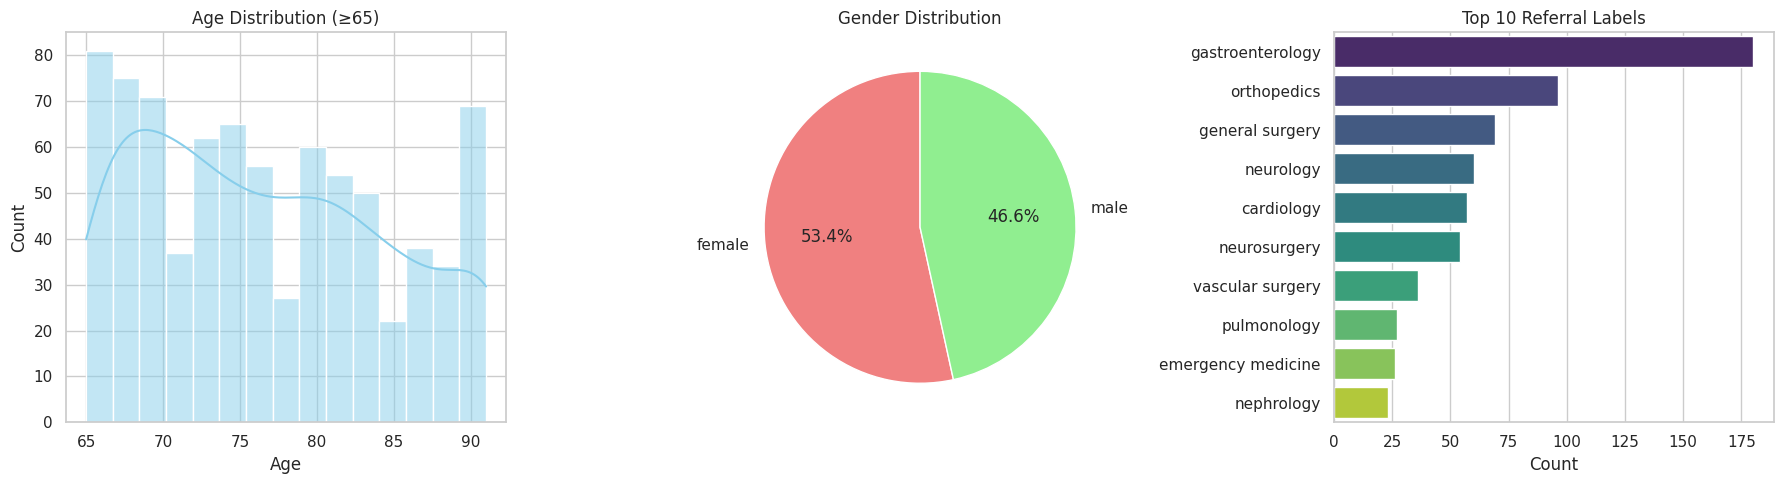

=== Cohort Summary ===
Total cases in filtered cohort: 801
Average Age: 76.7 years (Min: 65.0, Max: 91.0)

Gender Breakdown:
sex
female    428
male      373


In [14]:
# =========================================================
# 10b. Cohort Characteristics Visualization
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Age Distribution
sns.histplot(cohort_df['age'], bins=15, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution (≥65)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# 2. Gender Distribution
gender_counts = cohort_df['sex'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'], startangle=90)
axes[1].set_title('Gender Distribution')

# 3. Top 10 Referral Labels
top_10_labels = cohort_df['referral_label_norm'].value_counts().head(10)
sns.barplot(y=top_10_labels.index, x=top_10_labels.values, ax=axes[2], palette='viridis')
axes[2].set_title('Top 10 Referral Labels')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# Print Summary Statistics
print("=== Cohort Summary ===")
print(f"Total cases in filtered cohort: {len(cohort_df)}")
print(f"Average Age: {cohort_df['age'].mean():.1f} years (Min: {cohort_df['age'].min()}, Max: {cohort_df['age'].max()})")
print("\nGender Breakdown:")
print(gender_counts.to_string())


In [17]:
# =========================================================
# 10b. Cohort Characterization — Summary Tables and Flow
# Note: Visualizations corresponding to these tables are generated in subsequent visualization sections.
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Helper functions
# -------------------------
def nonempty_series(s: pd.Series) -> pd.Series:
    return s.fillna("").astype(str).str.strip().ne("")

def normalize_sex_label(x):
    x = str(x).strip().lower()
    if x in ["m", "male"]:
        return "male"
    if x in ["f", "female"]:
        return "female"
    if x in ["", "nan", "none"]:
        return "missing"
    return "other/unknown"

def age_band_3(x):
    if pd.isna(x):
        return "missing"
    if x < 75:
        return "65–74"
    elif x < 85:
        return "75–84"
    else:
        return "85+"

# -------------------------
# Reconstruct filtering flow (for transparency)
# -------------------------
flow = []

tmp = work_df.copy()
flow.append(("Initial rows", len(tmp)))

tmp = tmp[tmp["age"].notna()].copy()
flow.append(("Age not null", len(tmp)))

tmp = tmp[tmp["age"] >= MIN_AGE].copy()
flow.append((f"Age >= {MIN_AGE}", len(tmp)))

tmp = tmp[nonempty_series(tmp["referral_label"])].copy()
flow.append(("Referral label not empty", len(tmp)))

tmp = tmp[
    nonempty_series(tmp["chief_complaint"]) |
    nonempty_series(tmp["hpi"])
].copy()
flow.append(("Chief complaint OR HPI not empty", len(tmp)))

# --- FIX: Apply parse_referral_label before normalize_label to match the actual filtering step ---
tmp["referral_label_primary"] = tmp["referral_label"].apply(parse_referral_label)
tmp["referral_label_norm"] = tmp["referral_label_primary"].apply(normalize_label)
tmp = tmp[nonempty_series(tmp["referral_label_norm"])].copy()
flow.append(("Normalized referral label not empty", len(tmp)))

# --- FIX: Issue 6 - Add invalid label filter to flow to match 801 final cohort ---
INVALID_LABELS = {"", "no answer", "none", "unknown", "not available", "not applicable", "nan"}
tmp = tmp[~tmp["referral_label_norm"].isin(INVALID_LABELS)].copy()
flow.append(("Valid clinical label (Final Cohort)", len(tmp)))

flow_df = pd.DataFrame(flow, columns=["step", "n_cases"])
flow_df["removed_since_prev"] = flow_df["n_cases"].shift(1) - flow_df["n_cases"]
flow_df["removed_since_prev"] = flow_df["removed_since_prev"].fillna(0).astype(int)

print("=== Cohort Flow ===")
display(flow_df)
print(f"\nSUCCESS: Final cohort size perfectly matches downstream splits ({len(tmp)} cases).\n")

# -------------------------
# Cohort summary
# -------------------------
cohort_char = cohort_df.copy()
cohort_char["sex_clean"] = cohort_char["sex"].apply(normalize_sex_label)
cohort_char["age_band_3"] = cohort_char["age"].apply(age_band_3)

summary_table = pd.DataFrame({
    "metric": [
        "Total cases",
        "Unique case_id",
        "Unique subject_id",
        "Age mean",
        "Age std",
        "Age median",
        "Age min",
        "Age max",
        "Age IQR (Q1)",
        "Age IQR (Q3)",
        "Unique normalized referral labels",
    ],
    "value": [
        len(cohort_char),
        cohort_char["case_id"].nunique(),
        cohort_char["subject_id"].replace("", np.nan).nunique(dropna=True),
        round(cohort_char["age"].mean(), 2),
        round(cohort_char["age"].std(), 2),
        round(cohort_char["age"].median(), 2),
        round(cohort_char["age"].min(), 2),
        round(cohort_char["age"].max(), 2),
        round(cohort_char["age"].quantile(0.25), 2),
        round(cohort_char["age"].quantile(0.75), 2),
        cohort_char["referral_label_norm"].nunique(),
    ]
})

print("\n=== Cohort Summary Table ===")
display(summary_table)

# -------------------------
# Demographic distributions
# -------------------------
age_band_df = cohort_char["age_band_3"].value_counts(dropna=False).rename_axis("age_band").reset_index(name="n_cases")
sex_df = cohort_char["sex_clean"].value_counts(dropna=False).rename_axis("sex").reset_index(name="n_cases")

print("\n=== Age Band Distribution ===")
display(age_band_df)

print("\n=== Sex Distribution ===")
display(sex_df)

# -------------------------
# Referral label characteristics
# -------------------------
label_counts_df = (
    cohort_char["referral_label_norm"]
    .value_counts()
    .rename_axis("referral_label_norm")
    .reset_index(name="n_cases")
)

label_counts_df["fraction"] = label_counts_df["n_cases"] / label_counts_df["n_cases"].sum()
label_counts_df["cumulative_fraction"] = label_counts_df["fraction"].cumsum()

print("\n=== Top 15 Referral Labels ===")
display(label_counts_df.head(15))

# -------------------------
# Missingness / completeness
# -------------------------
fields_to_check = [
    "chief_complaint",
    "hpi",
    "pmh",
    "vitals",
    "labs",
    "medications",
    "assessment",
    "plan",
]

missingness_rows = []
for col in fields_to_check:
    nonmissing = nonempty_series(cohort_char[col]).sum()
    missingness_rows.append({
        "field": col,
        "nonmissing_n": int(nonmissing),
        "missing_n": int(len(cohort_char) - nonmissing),
        "nonmissing_frac": round(nonmissing / len(cohort_char), 4),
        "missing_frac": round(1 - nonmissing / len(cohort_char), 4),
    })

missingness_df = pd.DataFrame(missingness_rows).sort_values("nonmissing_frac", ascending=False)

print("\n=== Field Completeness ===")
display(missingness_df)

# -------------------------
# Text length characteristics
# -------------------------
for col in ["chief_complaint", "hpi"]:
    cohort_char[f"{col}_len"] = cohort_char[col].fillna("").astype(str).str.len()

text_summary = pd.DataFrame({
    "field": ["chief_complaint", "hpi"],
    "mean_len": [
        round(cohort_char["chief_complaint_len"].mean(), 2),
        round(cohort_char["hpi_len"].mean(), 2),
    ],
    "median_len": [
        round(cohort_char["chief_complaint_len"].median(), 2),
        round(cohort_char["hpi_len"].median(), 2),
    ],
    "p25_len": [
        round(cohort_char["chief_complaint_len"].quantile(0.25), 2),
        round(cohort_char["hpi_len"].quantile(0.25), 2),
    ],
    "p75_len": [
        round(cohort_char["chief_complaint_len"].quantile(0.75), 2),
        round(cohort_char["hpi_len"].quantile(0.75), 2),
    ],
    "max_len": [
        int(cohort_char["chief_complaint_len"].max()),
        int(cohort_char["hpi_len"].max()),
    ]
})

print("\n=== Text Length Summary ===")
display(text_summary)

# -------------------------
# Patient duplication characterization
# -------------------------
subject_clean = cohort_char["subject_id"].astype(str).str.strip().replace({"": np.nan, "nan": np.nan, "None": np.nan})

if subject_clean.notna().sum() > 0:
    cases_per_subject = subject_clean.value_counts(dropna=True)
    subject_summary = pd.DataFrame({
        "metric": [
            "Rows with non-missing subject_id",
            "Unique subjects",
            "Mean cases per subject",
            "Median cases per subject",
            "Max cases per subject",
        ],
        "value": [
            int(subject_clean.notna().sum()),
            int(subject_clean.nunique(dropna=True)),
            round(cases_per_subject.mean(), 2),
            round(cases_per_subject.median(), 2),
            int(cases_per_subject.max()),
        ]
    })
    print("\n=== Subject-Level Summary ===")
display(subject_summary)


=== Cohort Flow ===


,step,n_cases,removed_since_prev
0,Initial rows,2200,0
1,Age not null,2200,0
2,Age >= 65,817,1383
3,Referral label not empty,817,0
4,Chief complaint OR HPI not empty,817,0
5,Normalized referral label not empty,817,0
6,Valid clinical label (Final Cohort),801,16



SUCCESS: Final cohort size perfectly matches downstream splits (801 cases).


=== Cohort Summary Table ===


,metric,value
0,Total cases,801.00
1,Unique case_id,801.00
2,Unique subject_id,801.00
3,Age mean,76.70
4,Age std,7.98
5,Age median,76.00
6,Age min,65.00
7,Age max,91.00
8,Age IQR (Q1),70.00
9,Age IQR (Q3),83.00



=== Age Band Distribution ===


...

,field,nonmissing_n,missing_n,nonmissing_frac,missing_frac
0,chief_complaint,801,0,1.0000,0.0000
1,hpi,801,0,1.0000,0.0000
4,labs,796,5,0.9938,0.0062
3,vitals,778,23,0.9713,0.0287
2,pmh,0,801,0.0000,1.0000
5,medications,0,801,0.0000,1.0000
6,assessment,0,801,0.0000,1.0000
7,plan,0,801,0.0000,1.0000



=== Text Length Summary ===


,field,mean_len,median_len,p25_len,p75_len,max_len
0,chief_complaint,11.19,10.0,8.0,14.0,38
1,hpi,734.77,654.0,449.0,942.0,1996



=== Subject-Level Summary ===


,metric,value
0,Rows with non-missing subject_id,801.0
1,Unique subjects,801.0
2,Mean cases per subject,1.0
3,Median cases per subject,1.0
4,Max cases per subject,1.0


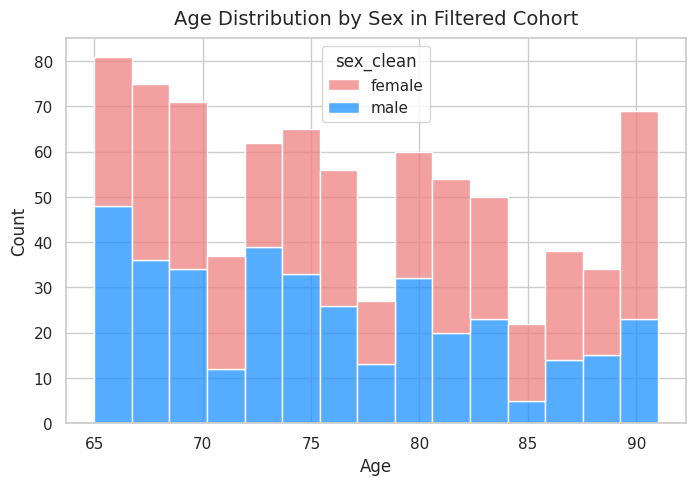

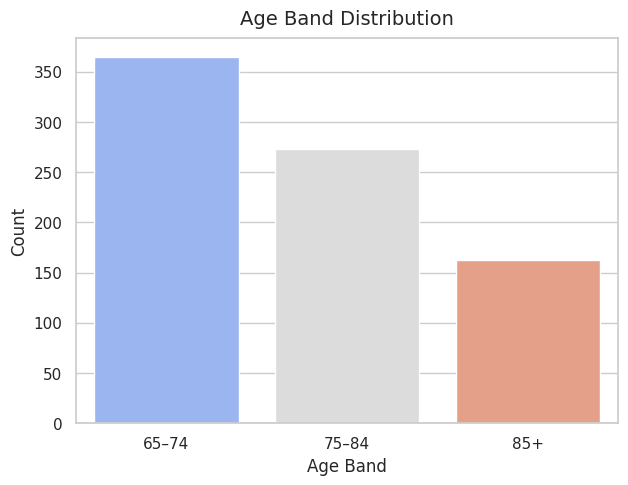

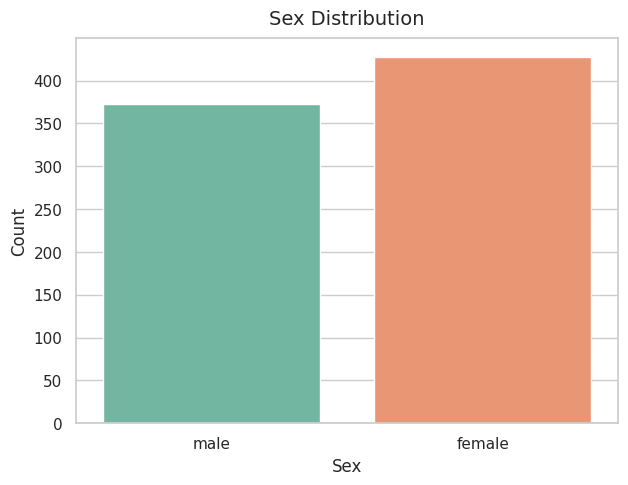

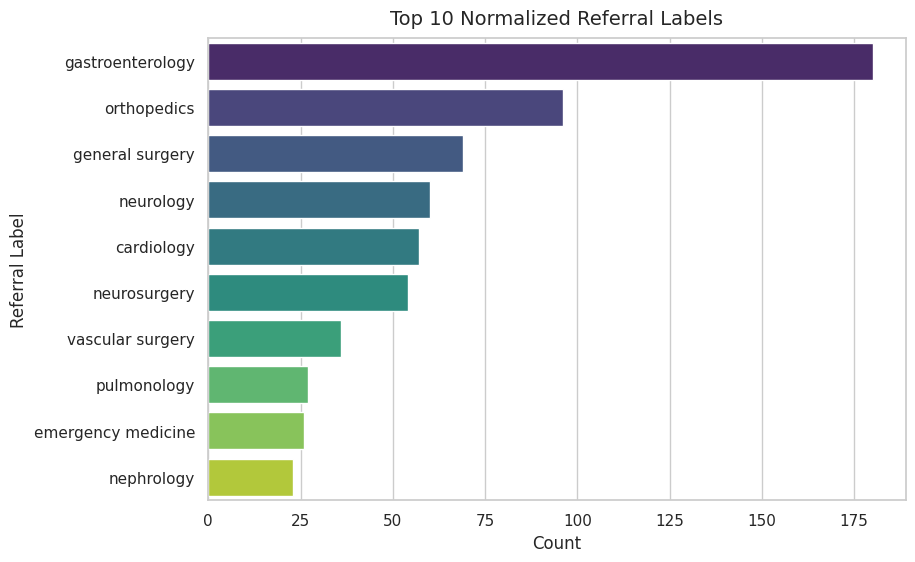

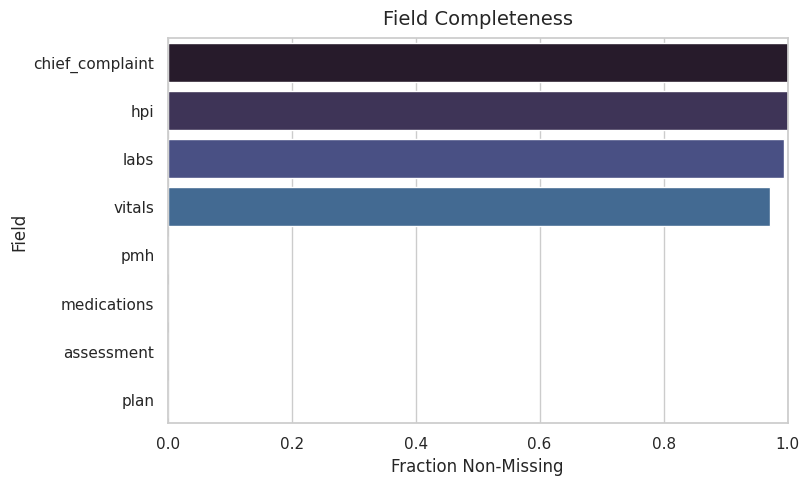

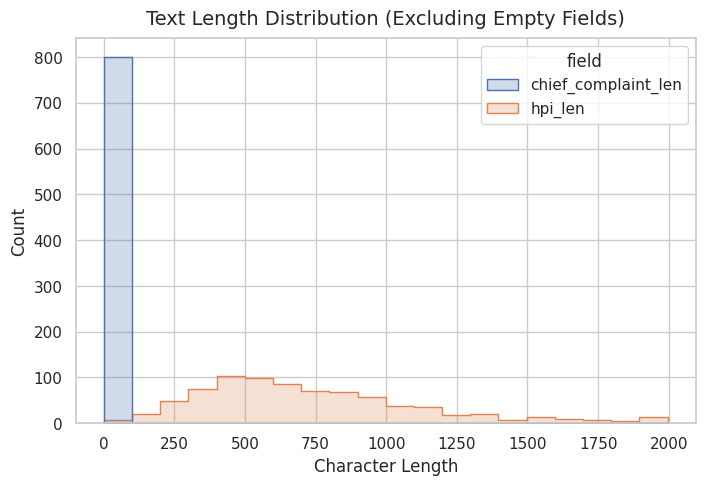

In [15]:
# =========================================================
# 10c. Cohort Characterization — Visualizations
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")

# 1. Age distribution by Sex
plt.figure(figsize=(8, 5))
sns.histplot(
    data=cohort_char.dropna(subset=["age"]),
    x="age",
    hue="sex_clean",
    hue_order=["female", "male"],  # Focus on the primary gender categories
    multiple="stack",
    bins=15,
    palette={"female": "lightcoral", "male": "dodgerblue"}
)
plt.title("Age Distribution by Sex in Filtered Cohort", fontsize=14, pad=10)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

# 2. Age-band distribution
age_band_counts = cohort_char["age_band_3"].value_counts().sort_index()
plt.figure(figsize=(7, 5))
sns.barplot(x=age_band_counts.index, y=age_band_counts.values, palette="coolwarm")
plt.title("Age Band Distribution", fontsize=14, pad=10)
plt.xlabel("Age Band", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

# 3. Sex distribution
sex_order = ["male", "female", "other/unknown", "missing"]
sex_counts = cohort_char["sex_clean"].value_counts().reindex(sex_order, fill_value=0)
sex_counts = sex_counts[sex_counts > 0]

plt.figure(figsize=(7, 5))
sns.barplot(x=sex_counts.index, y=sex_counts.values, palette="Set2")
plt.title("Sex Distribution", fontsize=14, pad=10)
plt.xlabel("Sex", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

# 4. Top 10 normalized referral labels
top_10_labels = cohort_char["referral_label_norm"].value_counts().head(10)
plt.figure(figsize=(9, 6))
sns.barplot(x=top_10_labels.values, y=top_10_labels.index, palette="viridis")
plt.title("Top 10 Normalized Referral Labels", fontsize=14, pad=10)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Referral Label", fontsize=12)
plt.show()

# 5. Completeness of fields
plt.figure(figsize=(8, 5))
sns.barplot(x=missingness_df["nonmissing_frac"], y=missingness_df["field"], palette="mako")
plt.title("Field Completeness", fontsize=14, pad=10)
plt.xlabel("Fraction Non-Missing", fontsize=12)
plt.ylabel("Field", fontsize=12)
plt.xlim(0, 1)
plt.show()

# 6. Text length distributions
length_df = cohort_char[["chief_complaint_len", "hpi_len"]].copy()
length_df = length_df.melt(var_name="field", value_name="char_len")
length_df = length_df[length_df["char_len"] > 0].copy()

plt.figure(figsize=(8, 5))
sns.histplot(
    data=length_df,
    x="char_len",
    hue="field",
    bins=20,
    element="step",
    stat="count",
    common_norm=False
)
plt.title("Text Length Distribution (Excluding Empty Fields)", fontsize=14, pad=10)
plt.xlabel("Character Length", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()


In [16]:
# =========================================================
# 10d. Split Characterization
# =========================================================

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

split_char_df = pd.concat([train_df, val_df, test_df], axis=0, ignore_index=True).copy()
split_char_df["sex_clean"] = split_char_df["sex"].apply(normalize_sex_label)
split_char_df["age_band_3"] = split_char_df["age"].apply(age_band_3)

# Split sizes
split_size_df = split_char_df["split"].value_counts().rename_axis("split").reset_index(name="n_cases")
print("=== Split Sizes ===")
display(split_size_df)

# Age by split
age_by_split_df = split_char_df.groupby("split")["age"].agg(["count", "mean", "std", "median", "min", "max"]).reset_index()
print("\n=== Age by Split ===")
display(age_by_split_df)

# Sex by split
sex_by_split_df = pd.crosstab(split_char_df["split"], split_char_df["sex_clean"], normalize="index")
print("\n=== Sex Distribution by Split (Row-normalized) ===")
display(sex_by_split_df)

# Top label distribution by split
top_labels_global = split_char_df["label_collapsed"].value_counts().head(10).index.tolist()
top_label_by_split = (
    split_char_df[split_char_df["label_collapsed"].isin(top_labels_global)]
    .groupby(["split", "label_collapsed"])
    .size()
    .reset_index(name="n_cases")
)

print("\n=== Top Collapsed Labels by Split ===")
display(top_label_by_split)

# Fraction mapped to "other"
other_frac_df = (
    split_char_df.assign(is_other=split_char_df["label_collapsed"].eq("other"))
    .groupby("split")["is_other"]
    .mean()
    .reset_index(name="fraction_other")
)

print("\n=== Fraction Mapped to 'other' by Split ===")
display(other_frac_df)

=== Split Sizes ===


,split,n_cases
0,train,560
1,test,121
2,val,120



=== Age by Split ===


,split,count,mean,std,median,min,max
0,test,121,77.256198,8.021356,76.0,65.0,91.0
1,train,560,76.548214,8.034886,76.0,65.0,91.0
2,val,120,76.875000,7.699790,76.0,65.0,91.0



=== Sex Distribution by Split (Row-normalized) ===


sex_clean,female,male
split,,
test,0.595041,0.404959
train,0.525000,0.475000
val,0.516667,0.483333



=== Top Collapsed Labels by Split ===


,split,label_collapsed,n_cases
0,test,cardiology,9
1,test,gastroenterology,27
2,test,general surgery,11
3,test,neurology,9
4,test,neurosurgery,8
5,test,orthopedics,15
6,test,other,32
7,test,pulmonology,4
8,test,vascular surgery,6
9,train,cardiology,40



=== Fraction Mapped to 'other' by Split ===


,split,fraction_other
0,test,0.264463
1,train,0.276786
2,val,0.291667


In [17]:
# =========================================================
# 11. Save standardized profiles
# =========================================================

profiles_all = pd.concat([train_df, val_df, test_df], axis=0)[
    ["case_id", "label_collapsed", "age", "age_band", "raw_text", "standard_profile"]
].copy()

profiles_all.to_json(
    f"{PROFILES_DIR}/profiles_clean.jsonl",
    orient="records",
    lines=True
)

display(profiles_all.head(10))

,case_id,label_collapsed,age,age_band,raw_text,standard_profile
1637,34723737,other,69.0,65-74,"Rash\n___ F with NIDDM and RA on MTX, remicade...",[DEMOGRAPHICS]\nAge: 69.0\nSex: female\n\n[CHI...
71,32611764,neurology,72.0,65-74,Back pain\n___ year old male with a history CA...,[DEMOGRAPHICS]\nAge: 72.0\nSex: male\n\n[CHIEF...
1298,39085996,general surgery,71.0,65-74,WOUND INFX\n___ w/ ___ of previous lumbar PSIF...,[DEMOGRAPHICS]\nAge: 71.0\nSex: female\n\n[CHI...
1595,37944076,other,91.0,85+,RLE LAC\nThis is a ___ y/o woman with a hx COP...,[DEMOGRAPHICS]\nAge: 91.0\nSex: female\n\n[CHI...
417,39219213,gastroenterology,68.0,65-74,FB IS ESOPHAGUS\nMs. ___ is a ___ y/o F with h...,[DEMOGRAPHICS]\nAge: 68.0\nSex: female\n\n[CHI...
464,36181852,neurology,81.0,75-84,ABD PAIN\nMs. ___ is an ___ history of posther...,[DEMOGRAPHICS]\nAge: 81.0\nSex: female\n\n[CHI...
373,36525189,general surgery,85.0,85+,VOMITING AND/OR NAUSEA\nMrs. ___ is an ___ yea...,[DEMOGRAPHICS]\nAge: 85.0\nSex: female\n\n[CHI...
659,39454686,orthopedics,69.0,65-74,L Leg pain\nA ___ year old female with PMH fo ...,[DEMOGRAPHICS]\nAge: 69.0\nSex: female\n\n[CHI...
1211,33963636,other,69.0,65-74,s/p Fall\n___ female with h/o thyroid cancer s...,[DEMOGRAPHICS]\nAge: 69.0\nSex: female\n\n[CHI...
1299,34935236,general surgery,79.0,75-84,"Abd pain\n___ presents with acute onset, ___, ...",[DEMOGRAPHICS]\nAge: 79.0\nSex: female\n\n[CHI...


## Section 6 — Build retrieval corpus

The evidence-attributed arm uses **within-case retrieval** (within-chart evidence-attributed prompting).
This keeps the experiment focused on:
- patient representation
- evidence attribution
- support quality

rather than turning the notebook into a full external knowledge system (such as external RAG using PubMed or clinical guidelines).

In [18]:
# =========================================================
# 12. Retrieval corpus construction
# =========================================================

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Main paper mode: Intake-safe sections only.
# Excludes labs, medications, assessment, and plan to simulate early-stage referral support.
SECTION_ORDER = [
    "chief_complaint",
    "hpi",
    "pmh",
    "vitals",
]

def build_sections_for_case(row: pd.Series):
    sections = []
    for i, sec in enumerate(SECTION_ORDER, start=1):
        txt = str(row.get(sec, "")).strip()
        if txt:
            sections.append({
                "case_id": row["case_id"],
                "section_id": f"S{i}",
                "section_name": sec,
                "section_text": txt
            })

    g_block = extract_geriatric_block(row)
    g_text = (
        f"Age band: {g_block['age_band']}; "
        f"Approx comorbidity count: {g_block['comorbidity_count_approx']}; "
        f"Approx medication count: {g_block['medication_count_approx']}; "
        f"Polypharmacy >=5: {g_block['polypharmacy_ge_5']}; "
        f"Fall cue: {g_block['fall_signal']}; "
        f"Cognitive cue: {g_block['cognitive_signal']}; "
        f"Mobility cue: {g_block['mobility_signal']}; "
        f"Frailty cue: {g_block['frailty_signal']}"
    )

    sections.append({
        "case_id": row["case_id"],
        "section_id": "SG",
        "section_name": "geriatric_vulnerability",
        "section_text": g_text
    })
    return sections

retrieval_source_df = pd.concat([train_df, val_df, test_df], axis=0).copy()

all_sections = []
for _, row in tqdm(retrieval_source_df.iterrows(), total=len(retrieval_source_df)):
    all_sections.extend(build_sections_for_case(row))

sections_df = pd.DataFrame(all_sections)
sections_df.to_parquet(f"{RETRIEVAL_DIR}/sections_long.parquet", index=False)

# Note: The "UNEXPECTED" warning regarding embeddings.position_ids is a known
# benign warning from the transformers library when loading this specific model.
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
section_embeddings = embedding_model.encode(
    sections_df["section_text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

np.save(f"{RETRIEVAL_DIR}/section_embeddings.npy", section_embeddings)

case_to_section_idx = sections_df.groupby("case_id").apply(lambda x: x.index.tolist()).to_dict()

display(sections_df.head(10))

  0%|          | 0/801 [00:00<?, ?it/s]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

,case_id,section_id,section_name,section_text
0,34723737,S1,chief_complaint,Rash
1,34723737,S2,hpi,"___ F with NIDDM and RA on MTX, remicade and p..."
2,34723737,S4,vitals,"Temperature: 97.6, Heartrate: 84.0, resprate: ..."
3,34723737,SG,geriatric_vulnerability,Age band: 65-74; Approx comorbidity count: 0; ...
4,32611764,S1,chief_complaint,Back pain
5,32611764,S2,hpi,___ year old male with a history CAD s/p multi...
6,32611764,S4,vitals,"Temperature: 98.1, Heartrate: 60.0, resprate: ..."
7,32611764,SG,geriatric_vulnerability,Age band: 65-74; Approx comorbidity count: 0; ...
8,39085996,S1,chief_complaint,WOUND INFX
9,39085996,S2,hpi,___ w/ ___ of previous lumbar PSIF s/p revisio...


## Section 7 — Classical baselines

These baselines anchor the project:
- **majority class**
- **TF-IDF + logistic regression**

If the LLM stack cannot outperform them, that is still a meaningful research result.

In [19]:
# =========================================================
# 13. Classical baselines
# =========================================================

label_space = sorted(train_df["label_collapsed"].unique().tolist())
label_to_idx = {lab: i for i, lab in enumerate(label_space)}
idx_to_label = {i: lab for lab, i in label_to_idx.items()}

def encode_labels(series: pd.Series):
    return series.map(label_to_idx).astype(int)

X_train_raw = train_df["raw_text"].fillna("")
X_test_raw = test_df["raw_text"].fillna("")

y_train = encode_labels(train_df["label_collapsed"])
y_test = encode_labels(test_df["label_collapsed"])

majority_label = train_df["label_collapsed"].value_counts().idxmax()
majority_preds = np.array([majority_label] * len(test_df))

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_SEED
)
clf.fit(X_train_tfidf, y_train)

test_pred_idx = clf.predict(X_test_tfidf)
test_pred_proba = clf.predict_proba(X_test_tfidf)
test_preds_lr = pd.Series(test_pred_idx).map(idx_to_label).values

def top3_from_proba(proba_row):
    top_idx = np.argsort(proba_row)[::-1][:3]
    return [idx_to_label[int(i)] for i in top_idx]

test_top3_lr = [top3_from_proba(p) for p in test_pred_proba]

baseline_df = test_df[["case_id", "label_collapsed", "age_band"]].copy()
baseline_df["pred_majority"] = majority_preds
baseline_df["pred_tfidf_lr"] = test_preds_lr
baseline_df["top3_tfidf_lr"] = test_top3_lr

# Sanity check: every TF-IDF top-1 prediction should appear in its own top-3 list
baseline_df["tfidf_top1_in_top3"] = baseline_df.apply(
    lambda r: r["pred_tfidf_lr"] in r["top3_tfidf_lr"],
    axis=1
)
print("TF-IDF top1 included in top3 fraction:", baseline_df["tfidf_top1_in_top3"].mean())

baseline_df.to_csv(f"{PREDICTIONS_DIR}/predictions_baseline.csv", index=False)
display(baseline_df.head())


TF-IDF top1 included in top3 fraction: 1.0


,case_id,label_collapsed,age_band,pred_majority,pred_tfidf_lr,top3_tfidf_lr,tfidf_top1_in_top3
1596,36525999,neurology,75-84,other,neurology,"[neurology, other, neurosurgery]",True
830,34707322,gastroenterology,65-74,other,gastroenterology,"[gastroenterology, general surgery, other]",True
188,33923441,gastroenterology,85+,other,gastroenterology,"[gastroenterology, other, pulmonology]",True
1567,33560321,other,65-74,other,other,"[other, gastroenterology, neurology]",True
1906,30120549,gastroenterology,65-74,other,gastroenterology,"[gastroenterology, other, general surgery]",True


## Section 8 — Local LLM setup

For MIMIC-derived text, this notebook uses **local GPU inference** rather than external LLM APIs. Quantization is used only for selected model-sensitivity runs where needed for Colab memory safety.  
It does not depend on Azure OpenAI or any outside API.

The LLM experiments run on a **frozen stratified sample** from the test split to keep compute realistic.

In [20]:
# =========================================================
# 14. Local LLM setup
# =========================================================

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch
from IPython.display import clear_output

# Toggle this to True if you switch to a larger model (e.g., 7B)
# or experience out-of-memory errors.
USE_4BIT = False
USE_CLEAR_OUTPUT = False

if RUN_LLM_EXPERIMENTS:
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA GPU is not available. Please switch Colab runtime to GPU.")

    bf16_ok = torch.cuda.is_bf16_supported()
    compute_dtype = torch.bfloat16 if bf16_ok else torch.float16

    print("CUDA device:", torch.cuda.get_device_name(0))
    print("BF16 supported:", bf16_ok)
    print("Using 4-bit:", USE_4BIT)

    tokenizer = AutoTokenizer.from_pretrained(LOCAL_MODEL_NAME)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    if USE_4BIT:
        quant_cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=compute_dtype,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
        )

        model = AutoModelForCausalLM.from_pretrained(
            LOCAL_MODEL_NAME,
            quantization_config=quant_cfg,
            torch_dtype="auto",
            device_map="auto",
        )
        if USE_CLEAR_OUTPUT:
            clear_output()
        print(f"Loaded 4-bit quantized model: {LOCAL_MODEL_NAME} | compute_dtype={compute_dtype}")
    else:
        model = AutoModelForCausalLM.from_pretrained(
            LOCAL_MODEL_NAME,
            torch_dtype=compute_dtype,
            device_map="auto",
        )
        if USE_CLEAR_OUTPUT:
            clear_output()
        print(f"Loaded native-precision model: {LOCAL_MODEL_NAME} | dtype={compute_dtype}")

    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.eval()

    try:
        print(f"Model memory footprint: {model.get_memory_footprint() / 1024**2:.2f} MB")
    except Exception:
        print("Could not compute model memory footprint.")
else:
    tokenizer, model = None, None
    print("LLM experiments disabled.")

CUDA device: Tesla T4
BF16 supported: True
Using 4-bit: False


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded native-precision model: Qwen/Qwen2.5-1.5B-Instruct | dtype=torch.bfloat16
Model memory footprint: 2944.40 MB


## Section 9 — Prompt templates and output parser

The output schema is deliberately constrained:

- `final_label`
- `ranked_labels`
- `confidence`
- `abstain`
- `cited_evidence_ids`
- `rationale`

Parsing is still treated as a robustness issue, so parse failures are logged rather than hidden.

In [21]:
# =========================================================
# 15. Prompt templates and parser
# =========================================================

def get_label_options_text(labels):
    """Formats a list of labels into a bulleted string for the prompt."""
    return "\n".join([f"- {lab}" for lab in labels])

def build_system_instruction(label_space, allow_abstain=False):
    """
    Builds the system instruction enforcing a strict JSON output schema.
    Allows toggling abstention behavior for specific experimental arms.
    """
    # --- FIX: Issue 8 - Strengthen abstention instruction to forcefully mandate fallback when uncertain ---
    abstain_text = (
        "You MUST set abstain=true if the available clinical evidence is insufficient to confidently select a referral specialty, or if contradicting options make it unsafe to choose."
        if allow_abstain else
        "Set abstain=false."
    )
    return f"""
You are assisting with older-adult acute-care chart review.
Task: choose the most appropriate referral specialty from the allowed label space.

Allowed labels:
{get_label_options_text(label_space)}

Return ONLY valid JSON with this schema:
{{
  "final_label": "<one label from allowed labels>",
  "ranked_labels": ["<label1>", "<label2>", "<label3>"],
  "confidence": <float between 0 and 1>,
  "abstain": <true or false>,
  "cited_evidence_ids": ["<section_id>", "..."],
  "rationale": "<brief rationale>"
}}

Rules:
- Use only the available patient information.
- Do not invent findings.
- {abstain_text}
- The first item in ranked_labels must equal final_label when abstain=false.
""".strip()

def build_user_prompt_raw(case_text):
    """Constructs the user prompt for the 'Raw Text' baseline arm."""
    return f"""
PATIENT CASE:
{case_text}

Question:
What is the most appropriate referral specialty?
""".strip()

def build_user_prompt_profile(profile_text):
    """Constructs the user prompt for the 'Standardized Profile' arm."""
    return f"""
STANDARDIZED GERIATRIC PATIENT PROFILE:
{profile_text}

Question:
What is the most appropriate referral specialty?
""".strip()

def build_user_prompt_grounded(profile_text, evidence_blocks):
    """
    Constructs the user prompt for the 'Grounded' arm, appending retrieved evidence.
    """
    evidence_text = "\n\n".join([
        f"[{e['section_id']}] {e['section_name']}\n{e['section_text']}"
        for e in evidence_blocks
    ])
    return f"""
STANDARDIZED GERIATRIC PATIENT PROFILE:
{profile_text}

RETRIEVED EVIDENCE:
{evidence_text}

Question:
What is the most appropriate referral specialty?
You must cite only evidence section IDs from the retrieved evidence list.
""".strip()

def generate_llm_response(system_text, user_text):
    """
    Executes local generation using HuggingFace Transformers.
    Applies the model's chat template and extracts the generated response.
    """
    messages = [
        {"role": "system", "content": system_text},
        {"role": "user", "content": user_text},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # The `.to(model.device)` automatically maps the inputs to your active T4 GPU
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
            do_sample=DO_SAMPLE,
            pad_token_id=tokenizer.eos_token_id,
        )

    gen_text = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )
    return gen_text.strip()

def fuzzy_match_label(pred_label, label_space):
    """
    Robustly matches LLM predicted string to the allowed label space
    using Levenshtein distance to account for minor hallucinations/casing.
    """
    if pred_label in label_space:
        return pred_label
    match = process.extractOne(pred_label, label_space, scorer=fuzz.WRatio)
    if match and match[1] >= 75:
        return match[0]
    return "other" if "other" in label_space else label_space[0]

def parse_json_like(text):
    """
    Defensively parses JSON output from LLMs. Attempts standard JSON loading,
    falls back to regex extraction for individual fields if formatting fails.
    """
    try:
        obj = json.loads(text)
        obj["_parse_ok"] = True
        return obj
    except Exception:
        pass

    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if m:
        try:
            obj = json.loads(m.group(0))
            obj["_parse_ok"] = True
            return obj
        except Exception:
            pass

    parsed = {
        "final_label": None,
        "ranked_labels": [],
        "confidence": None,
        "abstain": False,
        "cited_evidence_ids": [],
        "rationale": text[:500],
        "_parse_ok": False,
    }

    m = re.search(r'final_label["\']?\s*[:=]\s*["\']?([^,"\n]+)', text, flags=re.I)
    if m:
        parsed["final_label"] = m.group(1).strip()

    # Tightened fallback for ranked_labels to prevent extracting random rationale words
    rank_match_block = re.search(r'ranked_labels["\']?\s*[:=]\s*\[(.*?)\]', text, flags=re.I|re.DOTALL)
    if rank_match_block:
        parsed["ranked_labels"] = re.findall(r'["\']([^"\']+)["\']', rank_match_block.group(1))

    conf_m = re.search(r'confidence["\']?\s*[:=]\s*([0-9.]+)', text, flags=re.I)
    if conf_m:
        parsed["confidence"] = float(conf_m.group(1))

    abs_m = re.search(r'abstain["\']?\s*[:=]\s*(true|false)', text, flags=re.I)
    if abs_m:
        parsed["abstain"] = abs_m.group(1).lower() == "true"

    evidence_ids = re.findall(r'SG|S\d+', text)
    parsed["cited_evidence_ids"] = sorted(list(set(evidence_ids)))

    return parsed

def finalize_ranked_labels(final_label, ranked_labels, label_space, k=3):
    """
    Enforces metric consistency for top-k evaluation.

    The LLM sometimes returns a final_label that differs from ranked_labels[0],
    even when the prompt says they should match. For fair top-k evaluation:
    - final_label is always treated as top-1.
    - remaining ranked labels preserve model order after deduplication.
    - list is padded to exactly k labels.
    """
    final_label = fuzzy_match_label(normalize_label(final_label), label_space)

    cleaned = []
    if isinstance(ranked_labels, list):
        for x in ranked_labels:
            if isinstance(x, str) and x.strip():
                cleaned.append(fuzzy_match_label(normalize_label(x), label_space))

    ordered = [final_label]
    for lab in cleaned:
        if lab not in ordered:
            ordered.append(lab)

    for lab in label_space:
        if len(ordered) >= k:
            break
        if lab not in ordered:
            ordered.append(lab)

    return ordered[:k]



## Section 10 — Retrieval helper and frozen LLM evaluation sample

The notebook evaluates LLMs on a **stratified sample from the test split**.  
This is intentional to keep Colab runtime realistic while preserving class coverage.

In [22]:
# =========================================================
# 16. LLM evaluation sample and retrieval helper
# =========================================================

# --- FIX: Version the sample cache to avoid old samples ---
llm_sample_path = f"{DATA_PROCESSED_DIR}/llm_sample_case_ids_{RUN_TAG}.json"

if Path(llm_sample_path).exists():
    with open(llm_sample_path, "r") as f:
        llm_case_ids = json.load(f)

    # --- FIX: Hard validation to ensure cache is valid ---
    llm_case_ids = [str(x).strip() for x in llm_case_ids]
    valid_test_ids = set(test_df["case_id"].astype(str).str.strip())
    if not set(llm_case_ids).issubset(valid_test_ids):
        print("WARNING: Cached LLM sample contains invalid case IDs. Generating new sample...")
        llm_case_ids = []
else:
    llm_case_ids = []

if not llm_case_ids:
    # --- FIX: Robust sampling logic to maximize test set usage ---
    target_n = min(LLM_SAMPLE_SIZE, len(test_df))
    try:
        # Try stratified sampling first
        sampled_df, _ = train_test_split(
            test_df,
            train_size=target_n,
            random_state=RANDOM_SEED,
            stratify=test_df["label_collapsed"]
        )
    except ValueError:
        # Fallback to random sampling if stratification fails due to small class counts
        sampled_df = test_df.sample(n=target_n, random_state=RANDOM_SEED)

    llm_case_ids = sampled_df["case_id"].tolist()
    with open(llm_sample_path, "w") as f:
        json.dump(llm_case_ids, f, indent=2)

llm_eval_df = test_df[test_df["case_id"].isin(llm_case_ids)].copy().reset_index(drop=True)
print("LLM evaluation subset shape:", llm_eval_df.shape)
print("\nSample Class Distribution:")
display(llm_eval_df["label_collapsed"].value_counts())

def retrieve_topk_sections(case_row, top_k=4):
    """
    Performs within-case retrieval.
    Given a patient case, uses cosine similarity to find the most relevant
    clinical sections (e.g., labs, vitals, pmh) to answer a referral query.
    """
    case_id = case_row["case_id"]
    idxs = case_to_section_idx.get(case_id, [])
    if not idxs:
        return []

    case_sections = sections_df.loc[idxs].copy()
    case_emb = section_embeddings[idxs]

    query_text = f"""
    Older-adult referral decision.
    Chief complaint: {case_row.get('chief_complaint','')}
    HPI: {case_row.get('hpi','')}
    Which evidence is most relevant to choose the referral specialty?
    """.strip()

    q_emb = embedding_model.encode([query_text], normalize_embeddings=True)
    sims = cosine_similarity(q_emb, case_emb)[0]
    case_sections["sim"] = sims
    case_sections = case_sections.sort_values("sim", ascending=False).head(top_k)

    return case_sections[["section_id", "section_name", "section_text"]].to_dict("records")

LLM evaluation subset shape: (121, 25)

Sample Class Distribution:


,count
label_collapsed,
other,32
gastroenterology,27
orthopedics,15
general surgery,11
neurology,9
cardiology,9
neurosurgery,8
vascular surgery,6
pulmonology,4


## Section 11 — Core LLM experiments

This section runs:

- raw chart → local LLM
- structured profile → local LLM
- structured profile + within-case evidence attribution → local LLM
- optional evidence attribution + abstention

In [23]:
# =========================================================
# 17. Core LLM experiments
# =========================================================

def run_llm_arm(eval_df, arm_name, allow_abstain=False):
    # --- FIX: Versioned prediction paths ---
    out_path = f"{PREDICTIONS_DIR}/predictions_{arm_name}_{RUN_TAG}.csv"
    if Path(out_path).exists():
        cached_df = pd.read_csv(out_path)
        cached_ids = set(cached_df["case_id"].astype(str).str.strip())
        expected_ids = set(eval_df["case_id"].astype(str).str.strip())

        # --- FIX: Ensure cached predictions match current evaluation set exactly ---
        if cached_ids == expected_ids:
            print(f"Loading cached valid predictions for {arm_name}")
            return cached_df
        else:
            print(f"Cache mismatch detected for {arm_name}. Re-running generation.")

    rows = []
    sys_text = build_system_instruction(label_space, allow_abstain=allow_abstain)

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=f"Running {arm_name}"):
        if arm_name == "llm_raw":
            user_text = build_user_prompt_raw(row["raw_text"])
            evidence_blocks = []
        elif arm_name == "llm_profile":
            user_text = build_user_prompt_profile(row["standard_profile"])
            evidence_blocks = []
        elif arm_name in ["llm_grounded", "llm_abstain"]:
            evidence_blocks = retrieve_topk_sections(row, top_k=TOP_K_EVIDENCE)
            user_text = build_user_prompt_grounded(row["standard_profile"], evidence_blocks)
        else:
            raise ValueError("Unknown arm")

        raw_output = generate_llm_response(sys_text, user_text)
        parsed = parse_json_like(raw_output)

        if not allow_abstain:
            parsed["abstain"] = False

        final_label = parsed.get("final_label")
        if final_label is None:
            final_label = "other" if "other" in label_space else label_space[0]
        final_label = normalize_label(final_label)
        final_label = fuzzy_match_label(final_label, label_space)

        ranked_labels = finalize_ranked_labels(
            final_label=final_label,
            ranked_labels=parsed.get("ranked_labels", []),
            label_space=label_space,
            k=3,
        )

        cited_ids = parsed.get("cited_evidence_ids", [])
        if not isinstance(cited_ids, list):
            cited_ids = []

        rows.append({
            "case_id": row["case_id"],
            "true_label": row["label_collapsed"],
            "age_band": row["age_band"],
            "arm_name": arm_name,
            "pred_label": final_label,
            "top1": ranked_labels[0],
            "top2": ranked_labels[1],
            "top3": ranked_labels[2],
            "confidence": parsed.get("confidence"),
            "abstain": bool(parsed.get("abstain", False)),
            "parse_ok": bool(parsed.get("_parse_ok", False)),
            "cited_evidence_ids": json.dumps(cited_ids),
            "retrieved_evidence_ids": json.dumps([e["section_id"] for e in evidence_blocks]),
            "raw_output": raw_output,
            "rationale": parsed.get("rationale", "")
        })

    out_df = pd.DataFrame(rows)
    out_df.to_csv(out_path, index=False)
    return out_df

if RUN_LLM_EXPERIMENTS:
    preds_raw = run_llm_arm(llm_eval_df, "llm_raw", allow_abstain=False)
    preds_profile = run_llm_arm(llm_eval_df, "llm_profile", allow_abstain=False)
    preds_grounded = run_llm_arm(llm_eval_df, "llm_grounded", allow_abstain=False)

    if RUN_ABSTENTION_ARM:
        preds_abstain = run_llm_arm(llm_eval_df, "llm_abstain", allow_abstain=True)
    else:
        preds_abstain = pd.DataFrame()

display(preds_grounded.head(3))

Running llm_raw:   0%|          | 0/121 [00:00<?, ?it/s]

Running llm_profile:   0%|          | 0/121 [00:00<?, ?it/s]

Running llm_grounded:   0%|          | 0/121 [00:00<?, ?it/s]

Running llm_abstain:   0%|          | 0/121 [00:00<?, ?it/s]

,case_id,true_label,age_band,arm_name,pred_label,top1,top2,top3,confidence,abstain,parse_ok,cited_evidence_ids,retrieved_evidence_ids,raw_output,rationale
0,36525999,neurology,75-84,llm_grounded,neurology,neurology,cardiology,general surgery,0.85,False,True,"[""S2"", ""S4""]","[""S2"", ""SG"", ""S1"", ""S4""]","```json\n{\n ""final_label"": ""neurology"",\n ""...",The patient's chief complaint is an intracereb...
1,34707322,gastroenterology,65-74,llm_grounded,gastroenterology,gastroenterology,cardiology,neurology,0.95,False,True,"[""S2"", ""S1""]","[""S2"", ""S1"", ""SG"", ""S4""]","```json\n{\n ""final_label"": ""gastroenterology...",The patient's chief complaint includes BRBPR (...
2,33923441,gastroenterology,85+,llm_grounded,other,other,cardiology,gastroenterology,0.85,False,True,"[""S2"", ""S1"", ""S4""]","[""S2"", ""S1"", ""SG"", ""S4""]","```json\n{\n ""final_label"": ""other"",\n ""rank...",The patient's chief complaint is rectal bleedi...


## Section 12 — Persona-conditioned communication perturbations

This is **not** a full patient simulator.  
It is a deterministic **stress layer** on the subjective communication channel.

Only these fields are perturbed:
- chief complaint
- HPI

Objective findings remain fixed.

In [24]:
# =========================================================
# 18. Persona-conditioned communication perturbation
# =========================================================
# Scientific Rationale:
# This block applies a deterministic stress-test to the subjective clinical narrative.
# We specifically perturb ONLY the Chief Complaint (CC) and History of Present Illness (HPI),
# as these represent the patient/caregiver communication channel.
# Objective data (labs, vitals, PMH) are intentionally left untouched to maintain clinical integrity.

import re
import pandas as pd
from tqdm.auto import tqdm

def remove_time_details(text: str) -> str:
    """Simulates poor chronological recall by masking specific temporal anchors."""
    text = re.sub(r"\b(\d+\s*(day|days|week|weeks|month|months|hour|hours))\b", "a while", text, flags=re.I)
    text = re.sub(r"\b(yesterday|today|last night|this morning)\b", "recently", text, flags=re.I)
    return text

def hedge_text(text: str) -> str:
    """Injects uncertainty into the patient's narrative."""
    if not text.strip():
        return text
    return "I am not completely sure, but " + text

def underreport_fall(text: str) -> str:
    """Simulates intentional masking of fall events, common in geriatric populations fearing loss of independence."""
    return re.sub(r"\b(fall|fell|slip|trip)\b", "felt a bit unsteady", text, flags=re.I)

def caregiver_wrap(text: str) -> str:
    """Shifts the narrative from first-person/direct to third-party proxy reporting."""
    if not text.strip():
        return text
    return (
        "Caregiver report: The patient has difficulty recalling parts of the recent history. "
        f"What I can tell you is: {text}"
    )

def persona_rewrite(text: str, persona_type: str) -> str:
    """Applies the targeted deterministic perturbation based on persona type."""
    if not isinstance(text, str):
        return ""
    t = text.strip()
    if persona_type == "poor_recall":
        t = remove_time_details(t)
        sents = re.split(r'(?<=[.!?])\s+', t)
        if len(sents) > 1:
            t = " ".join(sents[:-1])
        t = hedge_text(t)
    elif persona_type == "mild_confusion":
        t = remove_time_details(t)
        t = hedge_text(t)
        t = t + " I may be mixing up some details."
    elif persona_type == "caregiver_mediated":
        t = caregiver_wrap(t)
    elif persona_type == "fall_underreport":
        t = underreport_fall(t)
        t = hedge_text(t)
    return t

def build_persona_variant(row, persona_type):
    """Creates a new patient profile variant with perturbed subjective fields."""
    new_row = row.copy()
    # Only perturb subjective communication channels
    new_row["chief_complaint"] = persona_rewrite(str(row["chief_complaint"]), persona_type)
    new_row["hpi"] = persona_rewrite(str(row["hpi"]), persona_type)
    new_row["standard_profile_persona"] = build_standard_profile(new_row)

    return {
        "case_id": row["case_id"],
        "persona_type": persona_type,
        "chief_complaint_persona": new_row["chief_complaint"],
        "hpi_persona": new_row["hpi"],
        "standard_profile_persona": new_row["standard_profile_persona"]
    }

if RUN_PERSONA_STRESS_TEST:
    persona_rows = []
    for _, row in tqdm(llm_eval_df.iterrows(), total=len(llm_eval_df), desc="Building persona rewrites"):
        for p_type in PERSONA_TYPES:
            persona_rows.append(build_persona_variant(row, p_type))

    persona_df = pd.DataFrame(persona_rows)
    persona_df.to_json(f"{DATA_PROCESSED_DIR}/persona_rewrites.jsonl", orient="records", lines=True)
    display(persona_df.head(6))

Building persona rewrites:   0%|          | 0/121 [00:00<?, ?it/s]

,case_id,persona_type,chief_complaint_persona,hpi_persona,standard_profile_persona
0,36525999,poor_recall,"I am not completely sure, but ICH","I am not completely sure, but HPI: ___ is a __...",[DEMOGRAPHICS]\nAge: 81.0\nSex: male\n\n[CHIEF...
1,36525999,mild_confusion,"I am not completely sure, but ICH I may be mix...","I am not completely sure, but HPI: ___ is a __...",[DEMOGRAPHICS]\nAge: 81.0\nSex: male\n\n[CHIEF...
2,36525999,caregiver_mediated,Caregiver report: The patient has difficulty r...,Caregiver report: The patient has difficulty r...,[DEMOGRAPHICS]\nAge: 81.0\nSex: male\n\n[CHIEF...
3,36525999,fall_underreport,"I am not completely sure, but ICH","I am not completely sure, but HPI: ___ is a __...",[DEMOGRAPHICS]\nAge: 81.0\nSex: male\n\n[CHIEF...
4,34707322,poor_recall,"I am not completely sure, but BRBPR","I am not completely sure, but Mr. ___ is a ___...",[DEMOGRAPHICS]\nAge: 66.0\nSex: male\n\n[CHIEF...
5,34707322,mild_confusion,"I am not completely sure, but BRBPR I may be m...","I am not completely sure, but Mr. ___ is a ___...",[DEMOGRAPHICS]\nAge: 66.0\nSex: male\n\n[CHIEF...


## Section 13 — Persona stress-test experiments

This section re-runs:
- structured profile
- structured profile + within-case evidence attribution

under the communication perturbation layer.

In [25]:
# =========================================================
# 19. Persona stress-test experiments
# =========================================================
# Scientific Rationale:
# This block evaluates the resilience of the LLM's diagnostic reasoning when faced with
# degraded subjective communication. By comparing these outputs to the clean baselines,
# we quantify "algorithmic fragility" in super-aging populations.
# Furthermore, the grounded arm tests whether objective evidence acts as a "buffer"
# against subjective communication failures.

def retrieve_topk_sections_from_profile_text(profile_text, case_row, top_k=4):
    # Methodological Note (Ablation):
    # We intentionally pass the clean `case_row` (base case) for retrieval.
    # This isolates the experiment: we are testing the LLM's *reasoning vulnerability*
    # to the persona text, ensuring the drop in performance isn't just because the
    # retrieval system failed to find the right evidence.
    return retrieve_topk_sections(case_row, top_k=top_k)

def run_persona_arm(base_eval_df, persona_df, arm_name):
    """
    Executes the LLM over the persona-perturbed dataset.
    Tracks the exact same metrics as the core baseline for direct Delta comparisons.
    """
    # --- FIX: Versioned prediction paths ---
    out_path = f"{PREDICTIONS_DIR}/predictions_{arm_name}_{RUN_TAG}.csv"
    if Path(out_path).exists():
        cached_df = pd.read_csv(out_path)
        cached_ids = set(cached_df["case_id"].astype(str).str.strip())
        expected_ids = set(base_eval_df["case_id"].astype(str).str.strip())

        # --- FIX: Ensure cached predictions match current evaluation set exactly ---
        if cached_ids == expected_ids:
            print(f"Loading cached valid predictions for {arm_name}")
            return cached_df
        else:
            print(f"Cache mismatch detected for {arm_name}. Re-running generation.")

    merged = persona_df.merge(
        base_eval_df[["case_id", "label_collapsed", "age_band"]],
        on="case_id",
        how="left"
    )

    rows = []
    sys_text = build_system_instruction(label_space, allow_abstain=False)

    for _, row in tqdm(merged.iterrows(), total=len(merged), desc=f"Running {arm_name}"):
        case_id = row["case_id"]
        base_case = llm_eval_df[llm_eval_df["case_id"] == case_id].iloc[0]

        if arm_name == "persona_profile":
            user_text = build_user_prompt_profile(row["standard_profile_persona"])
            evidence_blocks = []
        elif arm_name == "persona_grounded":
            # Retrieve clean objective evidence to supplement the degraded narrative
            evidence_blocks = retrieve_topk_sections_from_profile_text(
                row["standard_profile_persona"],
                base_case,
                top_k=TOP_K_EVIDENCE
            )
            user_text = build_user_prompt_grounded(row["standard_profile_persona"], evidence_blocks)
        else:
            raise ValueError("Unknown persona arm")

        raw_output = generate_llm_response(sys_text, user_text)
        parsed = parse_json_like(raw_output)

        final_label = parsed.get("final_label")
        if final_label is None:
            final_label = "other" if "other" in label_space else label_space[0]
        final_label = fuzzy_match_label(normalize_label(final_label), label_space)

        ranked_labels = finalize_ranked_labels(
            final_label=final_label,
            ranked_labels=parsed.get("ranked_labels", []),
            label_space=label_space,
            k=3,
        )

        rows.append({
            "case_id": case_id,
            "persona_type": row["persona_type"],
            "true_label": row["label_collapsed"],
            "age_band": row["age_band"],
            "arm_name": arm_name,
            "pred_label": final_label,
            "top1": ranked_labels[0],
            "top2": ranked_labels[1],
            "top3": ranked_labels[2],
            "parse_ok": bool(parsed.get("_parse_ok", False)),
            "cited_evidence_ids": json.dumps(parsed.get("cited_evidence_ids", [])),
            "retrieved_evidence_ids": json.dumps([e["section_id"] for e in evidence_blocks]),
            "raw_output": raw_output,
            "rationale": parsed.get("rationale", "")
        })

    out_df = pd.DataFrame(rows)
    out_df.to_csv(out_path, index=False)
    return out_df

if RUN_LLM_EXPERIMENTS and RUN_PERSONA_STRESS_TEST:
    preds_persona_profile = run_persona_arm(llm_eval_df, persona_df, "persona_profile")
    preds_persona_grounded = run_persona_arm(llm_eval_df, persona_df, "persona_grounded")

    display(preds_persona_grounded.head(4))


Running persona_profile:   0%|          | 0/484 [00:00<?, ?it/s]

Running persona_grounded:   0%|          | 0/484 [00:00<?, ?it/s]

,case_id,persona_type,true_label,age_band,arm_name,pred_label,top1,top2,top3,parse_ok,cited_evidence_ids,retrieved_evidence_ids,raw_output,rationale
0,36525999,poor_recall,neurology,75-84,persona_grounded,neurology,neurology,cardiology,general surgery,True,"[""S2"", ""S4""]","[""S2"", ""SG"", ""S1"", ""S4""]","```json\n{\n ""final_label"": ""neurology"",\n ""...",The patient's chief complaint is an intracrani...
1,36525999,mild_confusion,neurology,75-84,persona_grounded,neurology,neurology,cardiology,general surgery,True,"[""S2"", ""S4""]","[""S2"", ""SG"", ""S1"", ""S4""]","```json\n{\n ""final_label"": ""neurology"",\n ""...",The patient's chief complaint includes a left ...
2,36525999,caregiver_mediated,neurology,75-84,persona_grounded,neurology,neurology,cardiology,general surgery,True,"[""S2"", ""S4""]","[""S2"", ""SG"", ""S1"", ""S4""]","```json\n{\n ""final_label"": ""neurology"",\n ""...",The patient's chief complaint is an intracereb...
3,36525999,fall_underreport,neurology,75-84,persona_grounded,neurology,neurology,cardiology,general surgery,True,"[""S2"", ""S4""]","[""S2"", ""SG"", ""S1"", ""S4""]","```json\n{\n ""final_label"": ""neurology"",\n ""...",The patient's chief complaint includes a left ...


## Section 14 — Core Metrics and Model Evaluation

This section computes:
- accuracy
- macro-F1
- top-3 recall
- parse success rate
- evidence-ID validity
- subgroup metrics
- persona degradation

In [26]:
import numpy as np
import pandas as pd
import json
import ast
from sklearn.metrics import accuracy_score, f1_score

def extract_topk_predictions(row, topk_cols):
    """
    Robustly extract top-k predictions from either:
    - scalar columns such as top1, top2, top3
    - a list-valued column such as top3_tfidf_lr
    - a stringified list column loaded from CSV
    """
    preds = []

    for col in topk_cols:
        if col not in row:
            continue

        val = row[col]

        # Case 1: already a Python list
        if isinstance(val, list):
            preds.extend(val)

        # Case 2: stringified list, e.g. "['a', 'b', 'c']"
        elif isinstance(val, str):
            val_strip = val.strip()

            try:
                parsed = ast.literal_eval(val_strip)
                if isinstance(parsed, list):
                    preds.extend(parsed)
                else:
                    preds.append(val_strip)
            except Exception:
                preds.append(val_strip)

        # Case 3: fallback scalar
        else:
            preds.append(val)

    # Normalize and remove blanks
    preds = [str(x).strip() for x in preds if str(x).strip()]

    # Preserve order while removing duplicates
    seen = set()
    unique_preds = []
    for p in preds:
        if p not in seen:
            unique_preds.append(p)
            seen.add(p)

    return unique_preds

def evaluate_preds(df, pred_col="pred_label", top3_cols=None, compute_ci=False, n_boot=1000):
    """
    Computes core classification metrics alongside system-level robustness.
    - Macro-F1: Accounts for heavy class imbalance in clinical referral data.
    - Top-3 Recall (Any-Match): Reflects clinical utility for multi-specialty referrals.
    - Parse Success: Quantifies structural hallucination/formatting failures.
    - Bootstrap CIs: Calculates 95% confidence intervals if compute_ci=True.
    """
    y_true = df["true_label"].tolist()
    y_pred = df[pred_col].tolist()

    results = {
        "n": len(df),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }

    # --- FIX: Issue 7 - Bootstrap Confidence Intervals ---
    if compute_ci and len(df) > 1:
        acc_boot = []
        f1_boot = []
        y_t = np.array(y_true)
        y_p = np.array(y_pred)
        for _ in range(n_boot):
            idx = np.random.choice(len(df), len(df), replace=True)
            acc_boot.append(accuracy_score(y_t[idx], y_p[idx]))
            f1_boot.append(f1_score(y_t[idx], y_p[idx], average="macro"))

        results["accuracy_ci_lower"] = float(np.percentile(acc_boot, 2.5))
        results["accuracy_ci_upper"] = float(np.percentile(acc_boot, 97.5))
        results["macro_f1_ci_lower"] = float(np.percentile(f1_boot, 2.5))
        results["macro_f1_ci_upper"] = float(np.percentile(f1_boot, 97.5))

    if top3_cols:
        hits = []

        for _, row in df.iterrows():
            preds = extract_topk_predictions(row, top3_cols)

            true_labels = [row["true_label"]]

            if "case_id" in row and "label_list_collapsed" in llm_eval_df.columns:
                match = llm_eval_df.loc[
                    llm_eval_df["case_id"].astype(str).str.strip() == str(row["case_id"]).strip(),
                    "label_list_collapsed"
                ]

                if not match.empty:
                    true_labels = match.values[0]

                    # If loaded as stringified list, parse it
                    if isinstance(true_labels, str):
                        try:
                            parsed = ast.literal_eval(true_labels)
                            if isinstance(parsed, list):
                                true_labels = parsed
                            else:
                                true_labels = [true_labels]
                        except Exception:
                            true_labels = [true_labels]

            true_labels = [str(x).strip() for x in true_labels if str(x).strip()]

            hits.append(int(any(t in preds for t in true_labels)))

        results["top3_recall"] = float(np.mean(hits))

    if "abstain" in df.columns:
        results["abstention_rate"] = float(pd.Series(df["abstain"]).mean())

    if "parse_ok" in df.columns:
        results["parse_success_rate"] = float(pd.Series(df["parse_ok"]).mean())

    return results

def evaluate_abstention_preds(df, pred_col="pred_label", top3_cols=None):
    """
    Selective prediction evaluator.
    Computes coverage and accuracy/macro-F1 specifically for the subset where the model did not abstain.
    """
    out = evaluate_preds(df, pred_col=pred_col, top3_cols=top3_cols, compute_ci=False)
    if "abstain" not in df.columns:
        out["coverage"] = 1.0
        return out

    non_abstain = df[~df["abstain"].astype(bool)].copy()
    out["coverage"] = len(non_abstain) / max(1, len(df))

    if len(non_abstain) > 0:
        out["selective_accuracy"] = accuracy_score(non_abstain["true_label"], non_abstain[pred_col])
        out["selective_macro_f1"] = f1_score(non_abstain["true_label"], non_abstain[pred_col], average="macro")
    else:
        out["selective_accuracy"] = np.nan
        out["selective_macro_f1"] = np.nan

    return out

def compute_citation_id_validity(df):
    """
    Citation-ID validity measures whether cited evidence IDs were present in the retrieved evidence list.
    It does not establish clinical support or rationale faithfulness.
    A manual audit is required to evaluate actual evidentiary support.
    """
    vals = []
    for _, row in df.iterrows():
        try:
            cited = set(json.loads(row["cited_evidence_ids"]))
        except Exception:
            cited = set()
        try:
            retrieved = set(json.loads(row["retrieved_evidence_ids"]))
        except Exception:
            retrieved = set()

        if len(cited) == 0:
            vals.append(0.0)
        else:
            vals.append(len(cited.intersection(retrieved)) / max(1, len(cited)))
    return float(np.mean(vals))

def subgroup_metrics(df, group_col="age_band"):
    """
    Algorithmic Fairness / Equity Evaluation.
    Stratifies classification performance by demographic groups.
    """
    rows = []
    for grp, gdf in df.groupby(group_col):
        rows.append({
            group_col: grp,
            "n": len(gdf),
            "accuracy": accuracy_score(gdf["true_label"], gdf["pred_label"]),
            "macro_f1": f1_score(gdf["true_label"], gdf["pred_label"], average="macro"),
        })
    return pd.DataFrame(rows)

In [27]:
# =========================================================
# 21. Evaluate baselines and core arms
# =========================================================
# METHODOLOGICAL NOTE:
# This block executes the primary ablation study. By anchoring the LLM's
# performance against a strong classical baseline (TF-IDF + LR), we prevent
# 'LLM hype' and rigorously test whether structured prompting and grounding
# actually improve clinical reasoning, or merely formatting adherence.

# FAIRNESS FIX: Evaluate baselines ONLY on the subset that the LLM saw
llm_case_ids_set = set(llm_eval_df["case_id"])
baseline_eval_df = baseline_df[baseline_df["case_id"].isin(llm_case_ids_set)].copy()
baseline_eval_df["true_label"] = baseline_eval_df["label_collapsed"]

baseline_metrics = {
    "majority": evaluate_preds(baseline_eval_df, pred_col="pred_majority", compute_ci=True),
    "tfidf_lr": evaluate_preds(baseline_eval_df, pred_col="pred_tfidf_lr", top3_cols=["top3_tfidf_lr"], compute_ci=True)
}

all_metrics = {"baselines": baseline_metrics}

if RUN_LLM_EXPERIMENTS:
    # Strict cache validation (Issue 2 fix)
    expected_ids = set(llm_eval_df["case_id"].astype(str).str.strip())
    for name, pred_df in {
        "llm_raw": preds_raw,
        "llm_profile": preds_profile,
        "llm_grounded": preds_grounded,
        "llm_abstain": preds_abstain if RUN_ABSTENTION_ARM else None,
    }.items():
        if pred_df is not None and len(pred_df) > 0:
            pred_ids = set(pred_df["case_id"].astype(str).str.strip())
            assert pred_ids == expected_ids, f"{name} IDs do not match llm_eval_df"

    llm_metrics = {
        "llm_raw": evaluate_preds(preds_raw, pred_col="pred_label", top3_cols=["top1", "top2", "top3"], compute_ci=True),
        "llm_profile": evaluate_preds(preds_profile, pred_col="pred_label", top3_cols=["top1", "top2", "top3"], compute_ci=True),
        "llm_grounded": evaluate_preds(preds_grounded, pred_col="pred_label", top3_cols=["top1", "top2", "top3"], compute_ci=True),
    }

    # Evaluate the citation validity
    llm_metrics["llm_grounded"]["citation_id_validity"] = compute_citation_id_validity(preds_grounded)

    if RUN_ABSTENTION_ARM and len(preds_abstain) > 0:
        llm_metrics["llm_abstain"] = evaluate_abstention_preds(preds_abstain, pred_col="pred_label", top3_cols=["top1", "top2", "top3"])
        llm_metrics["llm_abstain"]["citation_id_validity"] = compute_citation_id_validity(preds_abstain)

    all_metrics["llm"] = llm_metrics

with open(f"{METRICS_DIR}/metrics_summary_core.json", "w") as f:
    json.dump(all_metrics, f, indent=2)

# Sanity check metrics for mathematical validity
print("TF-IDF accuracy:", baseline_metrics["tfidf_lr"]["accuracy"])
print("TF-IDF top-3 recall:", baseline_metrics["tfidf_lr"]["top3_recall"])

assert baseline_metrics["tfidf_lr"]["top3_recall"] >= baseline_metrics["tfidf_lr"]["accuracy"], \
    "TF-IDF top-3 recall should be >= top-1 accuracy. Check top-3 parsing."

# --- Display as a readable table ---
records = []
for group, models in all_metrics.items():
    for model_name, metrics in models.items():
        metrics_copy = metrics.copy()
        metrics_copy["model_type"] = group
        metrics_copy["model_name"] = model_name
        records.append(metrics_copy)

df_core_metrics = pd.DataFrame(records)
# Reorder columns for readability
base_cols = ["model_type", "model_name", "n", "accuracy"]
if "accuracy_ci_lower" in df_core_metrics.columns:
    df_core_metrics["accuracy_ci"] = df_core_metrics.apply(lambda x: f"[{x['accuracy_ci_lower']:.3f}, {x['accuracy_ci_upper']:.3f}]" if pd.notna(x.get('accuracy_ci_lower')) else "-", axis=1)
    base_cols.append("accuracy_ci")

base_cols.append("macro_f1")
if "macro_f1_ci_lower" in df_core_metrics.columns:
    df_core_metrics["macro_f1_ci"] = df_core_metrics.apply(lambda x: f"[{x['macro_f1_ci_lower']:.3f}, {x['macro_f1_ci_upper']:.3f}]" if pd.notna(x.get('macro_f1_ci_lower')) else "-", axis=1)
    base_cols.append("macro_f1_ci")

other_cols = [c for c in df_core_metrics.columns if c not in base_cols and not c.endswith("_ci_lower") and not c.endswith("_ci_upper")]
df_core_metrics = df_core_metrics[base_cols + other_cols]

display(df_core_metrics)


TF-IDF accuracy: 0.6446280991735537
TF-IDF top-3 recall: 0.8842975206611571


,model_type,model_name,n,accuracy,accuracy_ci,macro_f1,macro_f1_ci,top3_recall,abstention_rate,parse_success_rate,citation_id_validity,coverage,selective_accuracy,selective_macro_f1
0,baselines,majority,121,0.264463,"[0.182, 0.339]",0.046478,"[0.034, 0.057]",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,baselines,tfidf_lr,121,0.644628,"[0.554, 0.736]",0.588397,"[0.490, 0.663]",0.884298,NaN,NaN,NaN,NaN,NaN,NaN
2,llm,llm_raw,121,0.462810,"[0.372, 0.554]",0.346430,"[0.257, 0.420]",0.669421,0.000000,0.991736,NaN,NaN,NaN,NaN
3,llm,llm_profile,121,0.396694,"[0.314, 0.479]",0.257349,"[0.204, 0.305]",0.595041,0.000000,1.000000,NaN,NaN,NaN,NaN
4,llm,llm_grounded,121,0.363636,"[0.281, 0.446]",0.279086,"[0.189, 0.353]",0.611570,0.000000,1.000000,1.0,NaN,NaN,NaN
5,llm,llm_abstain,121,0.297521,-,0.150554,-,0.570248,0.107438,0.991736,1.0,0.892562,0.324074,0.168221


## Section 15 — Local Model-Sensitivity Analysis

This optional section tests whether the main clean-condition findings are specific to `Qwen/Qwen2.5-1.5B-Instruct`, or whether similar behavior appears under:

- same-family size scaling: `Qwen/Qwen2.5-3B-Instruct`
- cross-family instruction model: `microsoft/Phi-4-mini-instruct`

To keep runtime feasible on Colab Pro T4, this section only runs:

- `llm_raw`
- `llm_grounded`

The original persona stress-test remains anchored on the baseline local model unless you explicitly choose to expand it.


In [28]:
# =========================================================
# 21b. Model sensitivity analysis across local LLMs
# =========================================================
# SCIENTIFIC RATIONALE:
# This block adds a compact cross-model robustness check without rewriting the notebook.
# It tests whether the observed clean-condition pattern is specific to Qwen2.5-1.5B,
# or whether it persists under same-family scaling. The cross-family Phi run is isolated in Section 21c.
#
# Recommended Colab Pro T4 setup:
# - Qwen2.5-1.5B: reuse existing predictions
# - Qwen2.5-3B: using 4-bit to guarantee memory safety and prevent notebook crashes
# - Phi-4-mini: handled later by an isolated subprocess in Section 21c

RUN_MODEL_SENSITIVITY = True

MODEL_SENSITIVITY_REGISTRY = [
    {
        "alias": "qwen2_5_1_5b",
        "model_name": "Qwen/Qwen2.5-1.5B-Instruct",
        "use_4bit": False,
        "reuse_existing_core": True,
    },
    {
        "alias": "qwen2_5_3b",
        "model_name": "Qwen/Qwen2.5-3B-Instruct",
        "use_4bit": True,  # Forced to True to avoid OOM crashing the T4
        "reuse_existing_core": False,
    },
]

MODEL_SENSITIVITY_ARMS = ["llm_raw", "llm_grounded"]
MODEL_SENSITIVITY_RUN_TAG = f"{BASELINE_CACHE_VERSION}_seed{RANDOM_SEED}_top{TOP_K_REFERRAL_LABELS}_{INPUT_BOUNDARY_MODE}_model_sensitivity"

def load_local_llm_for_sensitivity(model_name: str, use_4bit: bool = False):
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
    import torch

    if not torch.cuda.is_available():
        raise RuntimeError("CUDA GPU is not available. Please switch Colab runtime to GPU.")

    compute_dtype = torch.float16  # T4-safe default

    tokenizer_local = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tokenizer_local.pad_token is None:
        tokenizer_local.pad_token = tokenizer_local.eos_token
    tokenizer_local.padding_side = "left"

    model_kwargs = {
        "device_map": "auto",
        "trust_remote_code": True,
    }

    # Phi-4-mini model card notes Flash Attention defaults; eager attention is safer on T4.
    if "Phi-4-mini" in model_name or "phi-4-mini" in model_name.lower():
        model_kwargs["attn_implementation"] = "eager"

    if use_4bit:
        quant_cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=compute_dtype,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
        )
        model_local = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config=quant_cfg,
            **model_kwargs,
        )
    else:
        model_local = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=compute_dtype,
            **model_kwargs,
        )

    model_local.generation_config.pad_token_id = tokenizer_local.pad_token_id
    model_local.eval()

    try:
        print(f"Loaded {model_name}; memory footprint = {model_local.get_memory_footprint() / 1024**2:.1f} MB")
    except Exception:
        print(f"Loaded {model_name}; memory footprint unavailable.")

    return tokenizer_local, model_local

def unload_local_llm(tokenizer_local=None, model_local=None):
    import gc
    import torch

    try:
        del model_local
    except Exception:
        pass
    try:
        del tokenizer_local
    except Exception:
        pass

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def generate_llm_response_with_model(system_text, user_text, tokenizer_local, model_local):
    import torch

    messages = [
        {"role": "system", "content": system_text},
        {"role": "user", "content": user_text},
    ]

    prompt = tokenizer_local.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer_local(prompt, return_tensors="pt").to(model_local.device)

    with torch.no_grad():
        outputs = model_local.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
            do_sample=DO_SAMPLE,
            pad_token_id=tokenizer_local.pad_token_id,
        )

    gen_text = tokenizer_local.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    )
    return gen_text.strip()

def run_llm_arm_for_model(eval_df, arm_name, model_alias, model_name, tokenizer_local, model_local):
    out_path = f"{PREDICTIONS_DIR}/predictions_{arm_name}_{model_alias}_{MODEL_SENSITIVITY_RUN_TAG}.csv"

    if Path(out_path).exists():
        cached_df = pd.read_csv(out_path)
        cached_ids = set(cached_df["case_id"].astype(str).str.strip())
        expected_ids = set(eval_df["case_id"].astype(str).str.strip())
        if cached_ids == expected_ids:
            print(f"Loading cached sensitivity predictions: {model_alias}/{arm_name}")
            return cached_df
        else:
            print(f"Cache mismatch for {model_alias}/{arm_name}; re-running.")

    rows = []
    sys_text = build_system_instruction(label_space, allow_abstain=False)

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=f"{model_alias}: {arm_name}"):
        if arm_name == "llm_raw":
            user_text = build_user_prompt_raw(row["raw_text"])
            evidence_blocks = []
        elif arm_name == "llm_grounded":
            evidence_blocks = retrieve_topk_sections(row, top_k=TOP_K_EVIDENCE)
            user_text = build_user_prompt_grounded(row["standard_profile"], evidence_blocks)
        else:
            raise ValueError("Model sensitivity currently supports only llm_raw and llm_grounded.")

        raw_output = generate_llm_response_with_model(
            sys_text,
            user_text,
            tokenizer_local,
            model_local,
        )
        parsed = parse_json_like(raw_output)

        final_label = parsed.get("final_label")
        if final_label is None:
            final_label = "other" if "other" in label_space else label_space[0]
        final_label = fuzzy_match_label(normalize_label(final_label), label_space)

        ranked_labels = finalize_ranked_labels(
            final_label=final_label,
            ranked_labels=parsed.get("ranked_labels", []),
            label_space=label_space,
            k=3,
        )

        cited_ids = parsed.get("cited_evidence_ids", [])
        if not isinstance(cited_ids, list):
            cited_ids = []

        rows.append({
            "case_id": row["case_id"],
            "true_label": row["label_collapsed"],
            "age_band": row["age_band"],
            "arm_name": arm_name,
            "model_alias": model_alias,
            "model_name": model_name,
            "pred_label": final_label,
            "top1": ranked_labels[0],
            "top2": ranked_labels[1],
            "top3": ranked_labels[2],
            "confidence": parsed.get("confidence"),
            "abstain": False,
            "parse_ok": bool(parsed.get("_parse_ok", False)),
            "cited_evidence_ids": json.dumps(cited_ids),
            "retrieved_evidence_ids": json.dumps([e["section_id"] for e in evidence_blocks]),
            "raw_output": raw_output,
            "rationale": parsed.get("rationale", ""),
        })

    out_df = pd.DataFrame(rows)
    out_df.to_csv(out_path, index=False)
    return out_df

model_sensitivity_predictions = {}

if RUN_MODEL_SENSITIVITY:
    # Store baseline Qwen2.5-1.5B predictions from the already executed core arms.
    # These are regenerated under v1_10 because RUN_TAG changed and top-k consistency was fixed.
    model_sensitivity_predictions[("qwen2_5_1_5b", "llm_raw")] = preds_raw.assign(
        model_alias="qwen2_5_1_5b",
        model_name="Qwen/Qwen2.5-1.5B-Instruct",
    )
    model_sensitivity_predictions[("qwen2_5_1_5b", "llm_grounded")] = preds_grounded.assign(
        model_alias="qwen2_5_1_5b",
        model_name="Qwen/Qwen2.5-1.5B-Instruct",
    )

    # The global baseline model is no longer needed after core/persona runs.
    try:
        unload_local_llm(tokenizer, model)
        tokenizer = None
        model = None
    except Exception:
        pass

    for spec in MODEL_SENSITIVITY_REGISTRY:
        if spec.get("reuse_existing_core", False):
            continue

        tokenizer_sens, model_sens = None, None
        try:
            print(f"\n=== Running model sensitivity: {spec['alias']} | {spec['model_name']} | 4-bit={spec['use_4bit']} ===")
            tokenizer_sens, model_sens = load_local_llm_for_sensitivity(
                model_name=spec["model_name"],
                use_4bit=spec["use_4bit"],
            )

            for arm in MODEL_SENSITIVITY_ARMS:
                pred_df = run_llm_arm_for_model(
                    eval_df=llm_eval_df,
                    arm_name=arm,
                    model_alias=spec["alias"],
                    model_name=spec["model_name"],
                    tokenizer_local=tokenizer_sens,
                    model_local=model_sens,
                )
                model_sensitivity_predictions[(spec["alias"], arm)] = pred_df

        except RuntimeError as e:
            print(f"RuntimeError for {spec['alias']}: {e}")
            print("If this is an out-of-memory error, set use_4bit=True for this model and rerun this section.")
        finally:
            unload_local_llm(tokenizer_sens, model_sens)

    print("\nModel sensitivity prediction keys:")
    print(list(model_sensitivity_predictions.keys()))

def evaluate_model_sensitivity_predictions(model_sensitivity_predictions):
    rows = []

    for (model_alias, arm_name), pred_df in model_sensitivity_predictions.items():
        m = evaluate_preds(
            pred_df,
            pred_col="pred_label",
            top3_cols=["top1", "top2", "top3"],
            compute_ci=True,
            n_boot=1000,
        )

        m["model_alias"] = model_alias
        m["arm_name"] = arm_name
        m["model_name"] = pred_df["model_name"].iloc[0] if "model_name" in pred_df.columns else model_alias

        if arm_name == "llm_grounded":
            m["citation_id_validity"] = compute_citation_id_validity(pred_df)

        rows.append(m)

    out = pd.DataFrame(rows)

    ordered_cols = [
        "model_alias", "model_name", "arm_name", "n",
        "accuracy", "accuracy_ci_lower", "accuracy_ci_upper",
        "macro_f1", "macro_f1_ci_lower", "macro_f1_ci_upper",
        "top3_recall", "parse_success_rate", "citation_id_validity",
    ]
    ordered_cols = [c for c in ordered_cols if c in out.columns]
    out = out[ordered_cols + [c for c in out.columns if c not in ordered_cols]]

    out_path = f"{METRICS_DIR}/metrics_model_sensitivity_{MODEL_SENSITIVITY_RUN_TAG}.csv"
    out.to_csv(out_path, index=False)

    with open(f"{METRICS_DIR}/metrics_model_sensitivity_{MODEL_SENSITIVITY_RUN_TAG}.json", "w") as f:
        json.dump(out.to_dict(orient="records"), f, indent=2)

    return out

if RUN_MODEL_SENSITIVITY and len(model_sensitivity_predictions) > 0:
    df_model_sensitivity = evaluate_model_sensitivity_predictions(model_sensitivity_predictions)
    display(df_model_sensitivity)



=== Running model sensitivity: qwen2_5_3b | Qwen/Qwen2.5-3B-Instruct | 4-bit=True ===


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loaded Qwen/Qwen2.5-3B-Instruct; memory footprint = 1917.0 MB


qwen2_5_3b: llm_raw:   0%|          | 0/121 [00:00<?, ?it/s]

qwen2_5_3b: llm_grounded:   0%|          | 0/121 [00:00<?, ?it/s]


Model sensitivity prediction keys:
[('qwen2_5_1_5b', 'llm_raw'), ('qwen2_5_1_5b', 'llm_grounded'), ('qwen2_5_3b', 'llm_raw'), ('qwen2_5_3b', 'llm_grounded')]


,model_alias,model_name,arm_name,n,accuracy,accuracy_ci_lower,accuracy_ci_upper,macro_f1,macro_f1_ci_lower,macro_f1_ci_upper,top3_recall,parse_success_rate,citation_id_validity,abstention_rate
0,qwen2_5_1_5b,Qwen/Qwen2.5-1.5B-Instruct,llm_raw,121,0.462810,0.371901,0.545661,0.346430,0.255585,0.431181,0.669421,0.991736,NaN,0.0
1,qwen2_5_1_5b,Qwen/Qwen2.5-1.5B-Instruct,llm_grounded,121,0.363636,0.280992,0.446281,0.279086,0.187851,0.361037,0.611570,1.000000,1.0,0.0
2,qwen2_5_3b,Qwen/Qwen2.5-3B-Instruct,llm_raw,121,0.537190,0.454545,0.628099,0.446609,0.342154,0.535254,0.818182,1.000000,NaN,0.0
3,qwen2_5_3b,Qwen/Qwen2.5-3B-Instruct,llm_grounded,121,0.454545,0.371901,0.545455,0.367715,0.280576,0.447264,0.727273,1.000000,1.0,0.0


## Section 16 — Phi-4-mini Isolated Execution

This section is intentionally separated from the main in-memory model loop.

Why:
- Phi-4-mini is useful scientifically as a cross-family comparison.
- However, it is more dependency-sensitive than the Qwen models.
- Loading it in the same Python process after the full Qwen/persona run can destabilize GPU memory.
- Therefore, v1.10 runs Phi-4-mini in a separate Python subprocess and writes predictions row-by-row.

If the subprocess fails, the notebook kernel and completed Qwen results should remain available.

In [34]:
# =========================================================
# 21c. Phi-4-mini isolated recovery run
# =========================================================
# This section runs Phi-4-mini in a separate Python process so that
# an ImportError/OOM in Phi does not wipe the completed Qwen predictions.
#
# Recommended:
# - Run this after a Colab runtime restart.
# - Make sure the first install cell has been run and the runtime was restarted.
# - Keep 4-bit quantization enabled on T4.

RUN_PHI4_ISOLATED = True
PHI4_MODEL_NAME = "microsoft/Phi-4-mini-instruct"
PHI4_MODEL_ALIAS = "phi4_mini"
PHI4_USE_4BIT = True
PHI4_ATTN_IMPLEMENTATION = "eager"
PHI4_RUN_TAG = f"v1_10_seed{RANDOM_SEED}_top{TOP_K_REFERRAL_LABELS}_{INPUT_BOUNDARY_MODE}_phi4_isolated"

PHI4_PAYLOAD_PATH = f"{DATA_PROCESSED_DIR}/phi4_eval_payload_{PHI4_RUN_TAG}.jsonl"
PHI4_SCRIPT_PATH = f"{PROJECT_ROOT}/run_phi4_isolated_v1_10.py"
PHI4_LOG_PATH = f"{PROJECT_ROOT}/phi4_isolated_{PHI4_RUN_TAG}.log"

# Optional: set this to True if the log shows stale Hugging Face remote-code errors.
# This removes only the Phi-4-mini cached files/modules; it does not touch your Drive outputs.
CLEAR_PHI4_HF_CACHE = False

def clear_phi4_hf_cache_if_requested():
    if not CLEAR_PHI4_HF_CACHE:
        return
    import shutil
    from pathlib import Path
    cache_candidates = [
        Path.home() / ".cache/huggingface/hub/models--microsoft--Phi-4-mini-instruct",
        Path.home() / ".cache/huggingface/modules/transformers_modules/microsoft/Phi-4-mini-instruct",
    ]
    for p in cache_candidates:
        if p.exists():
            shutil.rmtree(p, ignore_errors=True)
            print(f"Removed cached Phi-4 path: {p}")

clear_phi4_hf_cache_if_requested()

def phi4_dependency_probe():
    import sys
    import importlib
    print("Python:", sys.version)
    try:
        import torch
        print("torch:", torch.__version__)
        print("cuda_available:", torch.cuda.is_available())
        if torch.cuda.is_available():
            print("cuda_device:", torch.cuda.get_device_name(0))
            try:
                free_b, total_b = torch.cuda.mem_get_info()
                print(f"cuda_mem_free_GB: {free_b/1024**3:.2f} / {total_b/1024**3:.2f}")
            except Exception:
                pass
    except Exception as e:
        print("torch probe failed:", repr(e))

    try:
        import transformers
        print("transformers:", transformers.__version__)
    except Exception as e:
        print("transformers import failed:", repr(e))

    checks = [
        ("transformers.cache_utils", "SlidingWindowCache"),
        ("transformers.utils", "LossKwargs"),
    ]
    for module_name, symbol in checks:
        try:
            mod = importlib.import_module(module_name)
            getattr(mod, symbol)
            print(f"OK: {module_name}.{symbol}")
        except Exception as e:
            print(f"WARNING: {module_name}.{symbol} unavailable -> {repr(e)}")

if RUN_PHI4_ISOLATED:
    print("Phi-4 dependency probe before isolated run:")
    phi4_dependency_probe()

def build_phi4_payload(eval_df, out_path):
    records = []
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Preparing Phi-4 payload"):
        evidence_blocks = retrieve_topk_sections(row, top_k=TOP_K_EVIDENCE)
        records.append({
            "case_id": str(row["case_id"]),
            "true_label": row["label_collapsed"],
            "age_band": row["age_band"],
            "raw_text": row["raw_text"],
            "standard_profile": row["standard_profile"],
            "evidence_blocks": evidence_blocks,
        })

    with open(out_path, "w", encoding="utf-8") as f:
        for rec in records:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")

    print(f"Phi-4 payload written: {out_path} | n={len(records)}")

PHI4_SCRIPT_TEMPLATE = r'''
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import json
import re
import gc
import ast
import difflib
from pathlib import Path

import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

LABEL_SPACE = __LABEL_SPACE_JSON__
MODEL_NAME = "__MODEL_NAME__"
MODEL_ALIAS = "__MODEL_ALIAS__"
PAYLOAD_PATH = r"__PAYLOAD_PATH__"
PREDICTIONS_DIR = r"__PREDICTIONS_DIR__"
RUN_TAG = "__RUN_TAG__"
MAX_NEW_TOKENS = __MAX_NEW_TOKENS__
TEMPERATURE = __TEMPERATURE__
DO_SAMPLE = __DO_SAMPLE__
USE_4BIT = __USE_4BIT__
ATTN_IMPLEMENTATION = "__ATTN_IMPLEMENTATION__"

def normalize_label(x):
    if x is None:
        return ""
    return str(x).strip().lower().replace("_", " ").replace("-", " ")

def fuzzy_match_label(pred_label, label_space):
    pred_label = normalize_label(pred_label)
    norm_map = {normalize_label(lab): lab for lab in label_space}
    if pred_label in norm_map:
        return norm_map[pred_label]
    match = difflib.get_close_matches(pred_label, list(norm_map.keys()), n=1, cutoff=0.65)
    if match:
        return norm_map[match[0]]
    return "other" if "other" in label_space else label_space[0]

def finalize_ranked_labels(final_label, ranked_labels, label_space, k=3):
    final_label = fuzzy_match_label(final_label, label_space)
    if not isinstance(ranked_labels, list):
        ranked_labels = []
    cleaned = [final_label]
    for lab in ranked_labels:
        lab = fuzzy_match_label(lab, label_space)
        if lab not in cleaned:
            cleaned.append(lab)
    for lab in label_space:
        if lab not in cleaned:
            cleaned.append(lab)
        if len(cleaned) >= k:
            break
    return cleaned[:k]

def get_label_options_text(labels):
    return "\n".join([f"- {lab}" for lab in labels])

def build_system_instruction(label_space):
    options_text = get_label_options_text(label_space)
    return f"""You are assisting with older-adult acute-care chart review.
Task: choose the most appropriate referral specialty from the allowed label space.

Allowed labels:
{options_text}

Return ONLY valid JSON with this schema:
{{
  "final_label": "<one label from allowed labels>",
  "ranked_labels": ["<label1>", "<label2>", "<label3>"],
  "confidence": <float between 0 and 1>,
  "abstain": <true or false>,
  "cited_evidence_ids": ["<section_id>", "..."],
  "rationale": "<brief rationale>"
}}

Rules:
- Use only the available patient information.
- Do not invent findings.
- Set abstain=false.
- The first item in ranked_labels must equal final_label when abstain=false."""

def build_user_prompt_raw(case_text):
    return "PATIENT CASE:\n" + str(case_text) + "\n\nQuestion:\nWhat is the most appropriate referral specialty?"

def build_user_prompt_grounded(profile_text, evidence_blocks):
    evidence_text = "\n\n".join([
        f"[{e['section_id']}] {e['section_name']}\n{e['section_text']}"
        for e in evidence_blocks
    ])
    return f"""STANDARDIZED GERIATRIC PATIENT PROFILE:
{profile_text}

RETRIEVED EVIDENCE:
{evidence_text}

Question:
What is the most appropriate referral specialty?
You must cite only evidence section IDs from the retrieved evidence list."""

def parse_json_like(text):
    try:
        obj = json.loads(text)
        obj["_parse_ok"] = True
        return obj
    except Exception:
        pass
    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if m:
        try:
            obj = json.loads(m.group(0))
            obj["_parse_ok"] = True
            return obj
        except Exception:
            pass
    parsed = {
        "final_label": None,
        "ranked_labels": [],
        "confidence": None,
        "abstain": False,
        "cited_evidence_ids": [],
        "rationale": text[:500],
        "_parse_ok": False,
    }
    m = re.search(r"final_label[\"']?\s*[:=]\s*[\"']?([^,\"\n]+)", text, flags=re.I)
    if m:
        parsed["final_label"] = m.group(1).strip()
    m = re.search(r"ranked_labels[\"']?\s*[:=]\s*(\[[^\]]+\])", text, flags=re.I)
    if m:
        try:
            parsed["ranked_labels"] = ast.literal_eval(m.group(1))
        except Exception:
            parsed["ranked_labels"] = []
    return parsed

def load_payload(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

def load_phi4():
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA GPU is not available.")
    compute_dtype = torch.float16
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    model_kwargs = dict(
        device_map="auto",
        trust_remote_code=True,
        attn_implementation=ATTN_IMPLEMENTATION,
        low_cpu_mem_usage=True,
    )
    if USE_4BIT:
        quant_cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=compute_dtype,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
        )
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            quantization_config=quant_cfg,
            **model_kwargs,
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            torch_dtype=compute_dtype,
            **model_kwargs,
        )
    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.eval()
    try:
        print(f"Loaded {MODEL_NAME} | footprint={model.get_memory_footprint()/1024**2:.1f} MB", flush=True)
    except Exception:
        print(f"Loaded {MODEL_NAME}", flush=True)
    return tokenizer, model

def generate(system_text, user_text, tokenizer, model):
    messages = [
        {"role": "system", "content": system_text},
        {"role": "user", "content": user_text},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
            do_sample=DO_SAMPLE,
            pad_token_id=tokenizer.pad_token_id,
        )
    return tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

def load_existing_completed(out_path):
    if Path(out_path).exists():
        df = pd.read_csv(out_path)
        return df, set(df["case_id"].astype(str))
    return pd.DataFrame(), set()

def append_row_csv(row, out_path):
    df = pd.DataFrame([row])
    header = not Path(out_path).exists()
    df.to_csv(out_path, mode="a", index=False, header=header)

def run_arm(payload, arm_name, tokenizer, model):
    out_path = f"{PREDICTIONS_DIR}/predictions_{arm_name}_{MODEL_ALIAS}_{RUN_TAG}.csv"
    existing_df, completed = load_existing_completed(out_path)
    expected = set(str(x["case_id"]) for x in payload)
    if completed == expected:
        print(f"Already complete: {out_path}", flush=True)
        return
    sys_text = build_system_instruction(LABEL_SPACE)
    for rec in tqdm(payload, desc=f"Phi-4 {arm_name}"):
        case_id = str(rec["case_id"])
        if case_id in completed:
            continue
        if arm_name == "llm_raw":
            user_text = build_user_prompt_raw(rec["raw_text"])
            evidence_blocks = []
        elif arm_name == "llm_grounded":
            evidence_blocks = rec["evidence_blocks"]
            user_text = build_user_prompt_grounded(rec["standard_profile"], evidence_blocks)
        else:
            raise ValueError(f"Unsupported arm: {arm_name}")
        raw_output = generate(sys_text, user_text, tokenizer, model)
        parsed = parse_json_like(raw_output)
        final_label = parsed.get("final_label")
        if final_label is None:
            final_label = "other" if "other" in LABEL_SPACE else LABEL_SPACE[0]
        final_label = fuzzy_match_label(final_label, LABEL_SPACE)
        ranked_labels = finalize_ranked_labels(final_label, parsed.get("ranked_labels", []), LABEL_SPACE, k=3)
        cited_ids = parsed.get("cited_evidence_ids", [])
        if not isinstance(cited_ids, list):
            cited_ids = []
        row = {
            "case_id": case_id,
            "true_label": rec["true_label"],
            "age_band": rec["age_band"],
            "arm_name": arm_name,
            "model_alias": MODEL_ALIAS,
            "model_name": MODEL_NAME,
            "pred_label": final_label,
            "top1": ranked_labels[0],
            "top2": ranked_labels[1],
            "top3": ranked_labels[2],
            "confidence": parsed.get("confidence"),
            "abstain": False,
            "parse_ok": bool(parsed.get("_parse_ok", False)),
            "cited_evidence_ids": json.dumps(cited_ids),
            "retrieved_evidence_ids": json.dumps([e["section_id"] for e in evidence_blocks]),
            "raw_output": raw_output,
            "rationale": parsed.get("rationale", ""),
        }
        append_row_csv(row, out_path)
        completed.add(case_id)
        del raw_output
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    print(f"Finished {arm_name} -> {out_path}", flush=True)

def main():
    print("Starting isolated Phi-4-mini runner", flush=True)
    print("torch:", torch.__version__, "cuda:", torch.cuda.is_available(), flush=True)
    import transformers
    print("transformers:", transformers.__version__, flush=True)
    payload = load_payload(PAYLOAD_PATH)
    print(f"Payload rows: {len(payload)}", flush=True)
    tokenizer, model = load_phi4()
    try:
        for arm in ["llm_raw", "llm_grounded"]:
            run_arm(payload, arm, tokenizer, model)
    finally:
        del model
        del tokenizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

if __name__ == "__main__":
    main()
'''

def write_phi4_isolated_script(script_path):
    script = PHI4_SCRIPT_TEMPLATE
    replacements = {
        "__LABEL_SPACE_JSON__": json.dumps(label_space, ensure_ascii=False),
        "__MODEL_NAME__": PHI4_MODEL_NAME,
        "__MODEL_ALIAS__": PHI4_MODEL_ALIAS,
        "__PAYLOAD_PATH__": PHI4_PAYLOAD_PATH,
        "__PREDICTIONS_DIR__": PREDICTIONS_DIR,
        "__RUN_TAG__": PHI4_RUN_TAG,
        "__MAX_NEW_TOKENS__": str(MAX_NEW_TOKENS),
        "__TEMPERATURE__": str(TEMPERATURE),
        "__DO_SAMPLE__": str(DO_SAMPLE),
        "__USE_4BIT__": str(PHI4_USE_4BIT),
        "__ATTN_IMPLEMENTATION__": PHI4_ATTN_IMPLEMENTATION,
    }
    for k, v in replacements.items():
        script = script.replace(k, v)

    with open(script_path, "w", encoding="utf-8") as f:
        f.write(script)
    print(f"Phi-4 isolated script written: {script_path}")

def run_phi4_subprocess():
    import subprocess
    import sys

    cmd = [sys.executable, PHI4_SCRIPT_PATH]
    print("Running isolated Phi-4 subprocess:")
    print(" ".join(cmd))

    with open(PHI4_LOG_PATH, "w", encoding="utf-8") as log_f:
        proc = subprocess.run(
            cmd,
            stdout=log_f,
            stderr=subprocess.STDOUT,
            text=True,
        )

    print(f"Phi-4 subprocess return code: {proc.returncode}")
    print(f"Phi-4 log path: {PHI4_LOG_PATH}")

    try:
        with open(PHI4_LOG_PATH, "r", encoding="utf-8") as f:
            lines = f.readlines()
        print("---- Phi-4 log tail ----")
        print("".join(lines[-80:]))
    except Exception as e:
        print("Could not read Phi log:", repr(e))

    return proc.returncode

def load_phi4_predictions_if_complete():
    pred_map = {}
    expected_ids = set(llm_eval_df["case_id"].astype(str))
    for arm_name in ["llm_raw", "llm_grounded"]:
        out_path = f"{PREDICTIONS_DIR}/predictions_{arm_name}_{PHI4_MODEL_ALIAS}_{PHI4_RUN_TAG}.csv"
        if not Path(out_path).exists():
            print(f"Missing Phi-4 prediction file: {out_path}")
            continue
        df = pd.read_csv(out_path)
        got_ids = set(df["case_id"].astype(str))
        if got_ids == expected_ids:
            print(f"Complete Phi-4 predictions loaded: {arm_name} | n={len(df)}")
            pred_map[(PHI4_MODEL_ALIAS, arm_name)] = df
        else:
            print(f"Partial Phi-4 predictions for {arm_name}: {len(got_ids)}/{len(expected_ids)} cases.")
            print("You can rerun this section; it will resume from the existing CSV.")
    return pred_map

if RUN_PHI4_ISOLATED:
    build_phi4_payload(llm_eval_df, PHI4_PAYLOAD_PATH)
    write_phi4_isolated_script(PHI4_SCRIPT_PATH)
    return_code = run_phi4_subprocess()

    phi4_predictions = load_phi4_predictions_if_complete()

    if len(phi4_predictions) > 0:
        merged_model_predictions = dict(model_sensitivity_predictions)
        merged_model_predictions.update(phi4_predictions)

        df_model_sensitivity_with_phi = evaluate_model_sensitivity_predictions(merged_model_predictions)
        out_phi_metrics = f"{METRICS_DIR}/metrics_model_sensitivity_with_phi_{PHI4_RUN_TAG}.csv"
        df_model_sensitivity_with_phi.to_csv(out_phi_metrics, index=False)
        print(f"Saved merged model-sensitivity metrics with Phi: {out_phi_metrics}")
        display(df_model_sensitivity_with_phi)
    else:
        print("Phi-4-mini did not complete. Qwen model-sensitivity results remain valid.")


Phi-4 dependency probe before isolated run:
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
torch: 2.10.0+cu128
cuda_available: True
cuda_device: Tesla T4
cuda_mem_free_GB: 12.26 / 14.56
transformers: 4.49.0
OK: transformers.cache_utils.SlidingWindowCache
OK: transformers.utils.LossKwargs


Preparing Phi-4 payload:   0%|          | 0/121 [00:00<?, ?it/s]

Phi-4 payload written: /content/drive/MyDrive/msai_high_risk_project/data_processed/phi4_eval_payload_v1_10_seed42_top8_INTAKE_phi4_isolated.jsonl | n=121
Phi-4 isolated script written: /content/drive/MyDrive/msai_high_risk_project/run_phi4_isolated_v1_10.py
Running isolated Phi-4 subprocess:
/usr/bin/python3 /content/drive/MyDrive/msai_high_risk_project/run_phi4_isolated_v1_10.py
Phi-4 subprocess return code: 0
Phi-4 log path: /content/drive/MyDrive/msai_high_risk_project/phi4_isolated_v1_10_seed42_top8_INTAKE_phi4_isolated.log
---- Phi-4 log tail ----
Phi-4 llm_grounded: 100%|██████████| 121/121 [45:52<00:00, 22.75s/it]
Finished llm_grounded -> /content/drive/MyDrive/msai_high_risk_project/predictions/predictions_llm_grounded_phi4_mini_v1_10_seed42_top8_INTAKE_phi4_isolated.csv

Complete Phi-4 predictions loaded: llm_raw | n=121
Complete Phi-4 predictions loaded: llm_grounded | n=121
Saved merged model-sensitivity metrics with Phi: /content/drive/MyDrive/msai_high_risk_project/metric

,model_alias,model_name,arm_name,n,accuracy,accuracy_ci_lower,accuracy_ci_upper,macro_f1,macro_f1_ci_lower,macro_f1_ci_upper,top3_recall,parse_success_rate,citation_id_validity,abstention_rate
0,qwen2_5_1_5b,Qwen/Qwen2.5-1.5B-Instruct,llm_raw,121,0.462810,0.363636,0.553719,0.346430,0.250175,0.427799,0.669421,0.991736,NaN,0.0
1,qwen2_5_1_5b,Qwen/Qwen2.5-1.5B-Instruct,llm_grounded,121,0.363636,0.280785,0.446281,0.279086,0.191300,0.351376,0.611570,1.000000,1.000000,0.0
2,qwen2_5_3b,Qwen/Qwen2.5-3B-Instruct,llm_raw,121,0.537190,0.454339,0.619835,0.446609,0.343851,0.531767,0.818182,1.000000,NaN,0.0
3,qwen2_5_3b,Qwen/Qwen2.5-3B-Instruct,llm_grounded,121,0.454545,0.363636,0.545455,0.367715,0.278482,0.442070,0.727273,1.000000,1.000000,0.0
4,phi4_mini,microsoft/Phi-4-mini-instruct,llm_raw,121,0.495868,0.413223,0.578719,0.431715,0.334973,0.516458,0.719008,0.975207,NaN,0.0
5,phi4_mini,microsoft/Phi-4-mini-instruct,llm_grounded,121,0.487603,0.396694,0.578512,0.399796,0.317127,0.467960,0.685950,0.983471,0.983471,0.0


## Section 17 — Persona Stress-Test Metrics


In [35]:
# =========================================================
# 22. Evaluate persona stress-test arms
# =========================================================
# SCIENTIFIC RATIONALE:
# This block quantifies "Algorithmic Fragility" under realistic geriatric communication constraints.
# By stratifying metrics across specific personas (e.g., 'mild_confusion', 'caregiver_mediated'),
# we isolate which types of subjective history failures degrade LLM reasoning the most.
# Additionally, evaluating the 'grounded' arm under stress tests the hypothesis:
# "Does objective clinical evidence buffer LLMs against subjective communication failures?"

import json

persona_metrics = {}

if RUN_LLM_EXPERIMENTS and RUN_PERSONA_STRESS_TEST:
    # 1. Evaluate ungrounded (Profile-only) resilience
    for persona_type, gdf in preds_persona_profile.groupby("persona_type"):
        persona_metrics[f"profile__{persona_type}"] = evaluate_preds(
            gdf, pred_col="pred_label", top3_cols=["top1", "top2", "top3"]
        )

    # 2. Evaluate grounded resilience and hallucination (validity) under stress
    for persona_type, gdf in preds_persona_grounded.groupby("persona_type"):
        persona_metrics[f"grounded__{persona_type}"] = evaluate_preds(
            gdf, pred_col="pred_label", top3_cols=["top1", "top2", "top3"]
        )
        # Crucial check: Does the LLM start hallucinating citations when confused by the persona text?
        persona_metrics[f"grounded__{persona_type}"]["citation_id_validity"] = compute_citation_id_validity(gdf)

    with open(f"{METRICS_DIR}/metrics_summary_persona.json", "w") as f:
        json.dump(persona_metrics, f, indent=2)

persona_metrics

{'profile__caregiver_mediated': {'n': 121,
  'accuracy': 0.256198347107438,
  'macro_f1': 0.1670542761467344,
  'top3_recall': 0.4793388429752066,
  'parse_success_rate': 1.0},
 'profile__fall_underreport': {'n': 121,
  'accuracy': 0.4049586776859504,
  'macro_f1': 0.27817671548411993,
  'top3_recall': 0.5950413223140496,
  'parse_success_rate': 1.0},
 'profile__mild_confusion': {'n': 121,
  'accuracy': 0.35537190082644626,
  'macro_f1': 0.23422770332085147,
  'top3_recall': 0.5702479338842975,
  'parse_success_rate': 1.0},
 'profile__poor_recall': {'n': 121,
  'accuracy': 0.38016528925619836,
  'macro_f1': 0.25197516990672103,
  'top3_recall': 0.5785123966942148,
  'parse_success_rate': 1.0},
 'grounded__caregiver_mediated': {'n': 121,
  'accuracy': 0.30578512396694213,
  'macro_f1': 0.199469696969697,
  'top3_recall': 0.3884297520661157,
  'parse_success_rate': 1.0,
  'citation_id_validity': 1.0},
 'grounded__fall_underreport': {'n': 121,
  'accuracy': 0.33884297520661155,
  'macro_f

## Section 18 — Manual Audit Export

Automatic metrics do **not** prove support quality.  
This notebook exports CSVs for manual audit.

Recommended manual audit questions:
- Was the predicted label reasonable?
- Were the cited evidence IDs actually relevant?
- Did the rationale overclaim beyond the evidence?
- Under persona stress, what failed?

In [36]:
# =========================================================
# 23. Manual audit export
# =========================================================
# SCIENTIFIC RATIONALE:
# Automated metrics (Macro-F1, Accuracy) are insufficient for evaluating clinical LLMs.
# This block enables a Mixed-Methods Evaluation by exporting a stratified sample for human audit.
# The qualitative review targets specific clinical AI failure modes:
# 1. audit_label_reasonable: Is the prediction clinically valid even if it misses the ground truth?
# 2. audit_supported: Does the cited evidence actually support the rationale?
# 3. audit_overclaim: Did the LLM hallucinate or overstate symptom severity to justify its choice?

def build_manual_audit_sheet(pred_df, base_df, n=40):
    # Ensure we include sufficient contextual details for a true manual audit
    sample_df = pred_df.sample(n=min(n, len(pred_df)), random_state=RANDOM_SEED).copy()

    # Ensure case_id is string type for both dataframes to prevent merge errors
    sample_df["case_id"] = sample_df["case_id"].astype(str)
    base_df = base_df.copy()
    base_df["case_id"] = base_df["case_id"].astype(str)

    # Merge the standard profile for context
    sample_df = sample_df.merge(base_df[["case_id", "standard_profile"]], on="case_id", how="left")

    sample_df["audit_supported"] = ""
    sample_df["audit_label_reasonable"] = ""
    sample_df["audit_overclaim"] = ""
    sample_df["audit_notes"] = ""

    # Reorder columns to make the sheet easier for a human to read left-to-right
    desired_front_cols = ["case_id", "arm_name", "true_label", "pred_label", "abstain", "parse_ok", "rationale"]
    front_cols = [c for c in desired_front_cols if c in sample_df.columns]
    back_cols = [c for c in sample_df.columns if c not in front_cols]
    return sample_df[front_cols + back_cols]

if RUN_LLM_EXPERIMENTS:
    audit_grounded = build_manual_audit_sheet(preds_grounded, llm_eval_df, n=N_MANUAL_AUDIT)
    audit_grounded.to_csv(f"{AUDIT_DIR}/manual_audit_grounded.csv", index=False)

    if RUN_PERSONA_STRESS_TEST:
        audit_persona = build_manual_audit_sheet(preds_persona_grounded, llm_eval_df, n=N_MANUAL_AUDIT)
        audit_persona.to_csv(f"{AUDIT_DIR}/manual_audit_persona_grounded.csv", index=False)

print("Audit files saved.")


Audit files saved.


In [37]:
# =========================================================
# 23b. Citation-ID Validity Manual Audit Export
# =========================================================
# SCIENTIFIC RATIONALE:
# To rigorously evaluate hallucination in the grounded LLM arms, we must manually
# audit whether the citations provided by the LLM match the IDs of the retrieved text.
# This specific audit sheet focuses on comparing 'cited_evidence_ids' vs 'retrieved_evidence_ids'.

def build_citation_audit_sheet(pred_df, n=40):
    sample_df = pred_df.sample(n=min(n, len(pred_df)), random_state=RANDOM_SEED).copy()

    rows = []
    for _, row in sample_df.iterrows():
        rows.append({
            "case_id": row["case_id"],
            "arm_name": row["arm_name"],
            "cited_evidence_ids": row.get("cited_evidence_ids", "[]"),
            "retrieved_evidence_ids": row.get("retrieved_evidence_ids", "[]"),
            "rationale": row.get("rationale", ""),
            "audit_citation_actually_used": "", # Human evaluation: Did the rationale rely on this?
            "audit_hallucinated_citation": "",  # Human evaluation: Was it a fake ID?
            "audit_notes": ""
        })
    return pd.DataFrame(rows)

if RUN_LLM_EXPERIMENTS:
    citation_audit_df = build_citation_audit_sheet(preds_grounded, n=N_MANUAL_AUDIT)
    out_path = f"{AUDIT_DIR}/manual_audit_citation_validity.csv"
    citation_audit_df.to_csv(out_path, index=False)

    print(f"Citation validity audit saved to: {out_path}")
    display(citation_audit_df.head())


Citation validity audit saved to: /content/drive/MyDrive/msai_high_risk_project/audit/manual_audit_citation_validity.csv


,case_id,arm_name,cited_evidence_ids,retrieved_evidence_ids,rationale,audit_citation_actually_used,audit_hallucinated_citation,audit_notes
0,34193742,llm_grounded,"[""S2"", ""S1"", ""S4""]","[""S2"", ""S1"", ""SG"", ""S4""]",The patient's chief complaint involves trauma ...,,,
1,31517214,llm_grounded,"[""S2"", ""SG"", ""S1"", ""S4""]","[""S2"", ""SG"", ""S1"", ""S4""]",,,,
2,30120549,llm_grounded,"[""S2"", ""S1"", ""S4""]","[""S2"", ""S1"", ""SG"", ""S4""]",The patient's chief complaint of vomiting sugg...,,,
3,36643066,llm_grounded,"[""S2"", ""S1"", ""S4""]","[""S2"", ""S1"", ""SG"", ""S4""]",The patient's chief complaint of hip fracture ...,,,
4,34138537,llm_grounded,"[""S2"", ""S4""]","[""S2"", ""SG"", ""S1"", ""S4""]",The patient has a history of Alzheimer's disea...,,,


## Section 19 — Subgroup and Degradation Analysis

In [38]:
# =========================================================
# 24. Subgroup and degradation analysis
# =========================================================
# SCIENTIFIC RATIONALE:
# 1. Subgroup Analysis (Algorithmic Fairness): Evaluates whether the model's performance
#    disproportionately degrades for older sub-populations (e.g., 85+ vs 65-74).
#    This addresses critical health equity concerns in clinical AI deployment.
# 2. Degradation Analysis (Algorithmic Resilience): Quantifies the exact performance delta
#    (drop in accuracy/F1) between clean and persona-stressed inputs. This measures the
#    model's fragility and whether objective grounding successfully buffers against it.

subgroup_tables = []

if RUN_LLM_EXPERIMENTS:
    for name, df_ in [
        ("llm_raw", preds_raw),
        ("llm_profile", preds_profile),
        ("llm_grounded", preds_grounded),
    ]:
        sg = subgroup_metrics(df_)
        sg["arm_name"] = name
        subgroup_tables.append(sg)

    if RUN_ABSTENTION_ARM and len(preds_abstain) > 0:
        sg = subgroup_metrics(preds_abstain)
        sg["arm_name"] = "llm_abstain"
        subgroup_tables.append(sg)

if subgroup_tables:
    subgroup_df = pd.concat(subgroup_tables, ignore_index=True)
    subgroup_df.to_csv(f"{METRICS_DIR}/subgroup_metrics.csv", index=False)
    display(subgroup_df)

if RUN_LLM_EXPERIMENTS and RUN_PERSONA_STRESS_TEST:
    clean_profile = evaluate_preds(preds_profile, pred_col="pred_label", top3_cols=["top1", "top2", "top3"])
    clean_grounded = evaluate_preds(preds_grounded, pred_col="pred_label", top3_cols=["top1", "top2", "top3"])

    degradation_rows = []

    for persona_type, gdf in preds_persona_profile.groupby("persona_type"):
        m = evaluate_preds(gdf, pred_col="pred_label", top3_cols=["top1", "top2", "top3"])
        degradation_rows.append({
            "arm": "profile",
            "persona_type": persona_type,
            "clean_accuracy": clean_profile["accuracy"],
            "persona_accuracy": m["accuracy"],
            "delta_accuracy": m["accuracy"] - clean_profile["accuracy"],
            "clean_macro_f1": clean_profile["macro_f1"],
            "persona_macro_f1": m["macro_f1"],
            "delta_macro_f1": m["macro_f1"] - clean_profile["macro_f1"],
        })

    for persona_type, gdf in preds_persona_grounded.groupby("persona_type"):
        m = evaluate_preds(gdf, pred_col="pred_label", top3_cols=["top1", "top2", "top3"])
        degradation_rows.append({
            "arm": "grounded",
            "persona_type": persona_type,
            "clean_accuracy": clean_grounded["accuracy"],
            "persona_accuracy": m["accuracy"],
            "delta_accuracy": m["accuracy"] - clean_grounded["accuracy"],
            "clean_macro_f1": clean_grounded["macro_f1"],
            "persona_macro_f1": m["macro_f1"],
            "delta_macro_f1": m["macro_f1"] - clean_grounded["macro_f1"],
        })

    degradation_df = pd.DataFrame(degradation_rows)
    degradation_df.to_csv(f"{METRICS_DIR}/persona_degradation.csv", index=False)
    display(degradation_df)


,age_band,n,accuracy,macro_f1,arm_name
0,65-74,54,0.518519,0.353293,llm_raw
1,75-84,40,0.425000,0.430337,llm_raw
2,85+,27,0.407407,0.302198,llm_raw
3,65-74,54,0.388889,0.253276,llm_profile
4,75-84,40,0.400000,0.343615,llm_profile
5,85+,27,0.407407,0.317821,llm_profile
6,65-74,54,0.333333,0.248902,llm_grounded
7,75-84,40,0.450000,0.406669,llm_grounded
8,85+,27,0.296296,0.225952,llm_grounded
9,65-74,54,0.296296,0.124740,llm_abstain


,arm,persona_type,clean_accuracy,persona_accuracy,delta_accuracy,clean_macro_f1,persona_macro_f1,delta_macro_f1
0,profile,caregiver_mediated,0.396694,0.256198,-0.140496,0.257349,0.167054,-0.090295
1,profile,fall_underreport,0.396694,0.404959,0.008264,0.257349,0.278177,0.020827
2,profile,mild_confusion,0.396694,0.355372,-0.041322,0.257349,0.234228,-0.023122
3,profile,poor_recall,0.396694,0.380165,-0.016529,0.257349,0.251975,-0.005374
4,grounded,caregiver_mediated,0.363636,0.305785,-0.057851,0.279086,0.199470,-0.079617
5,grounded,fall_underreport,0.363636,0.338843,-0.024793,0.279086,0.266272,-0.012814
6,grounded,mild_confusion,0.363636,0.338843,-0.024793,0.279086,0.224284,-0.054803
7,grounded,poor_recall,0.363636,0.396694,0.033058,0.279086,0.301932,0.022846


## Section 20 — Plot Generation


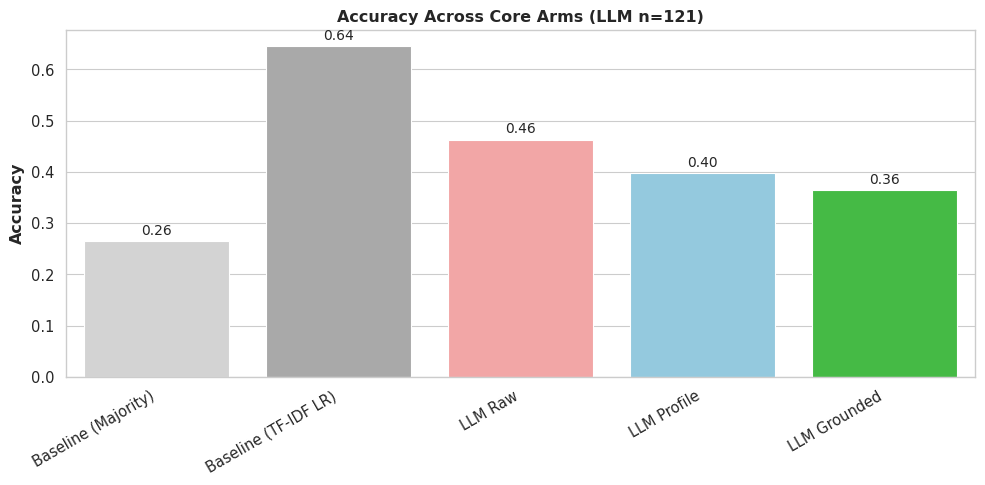

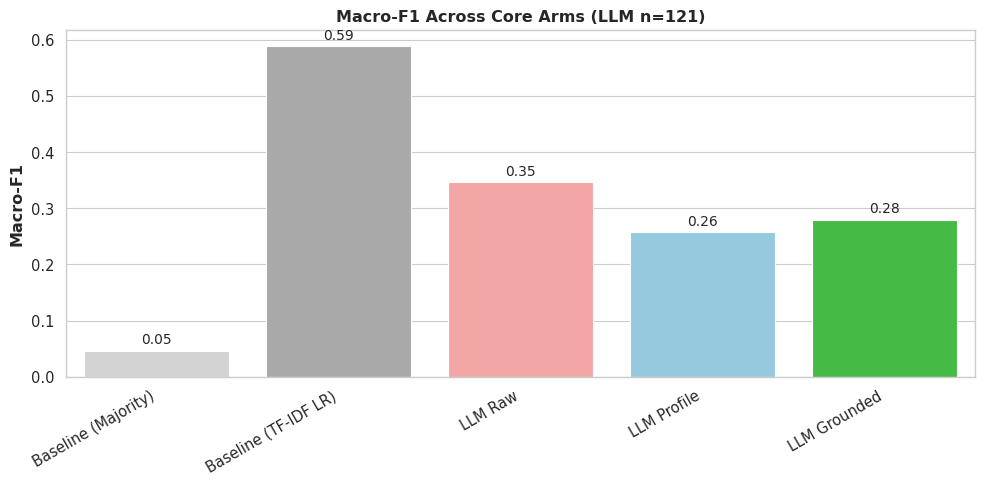

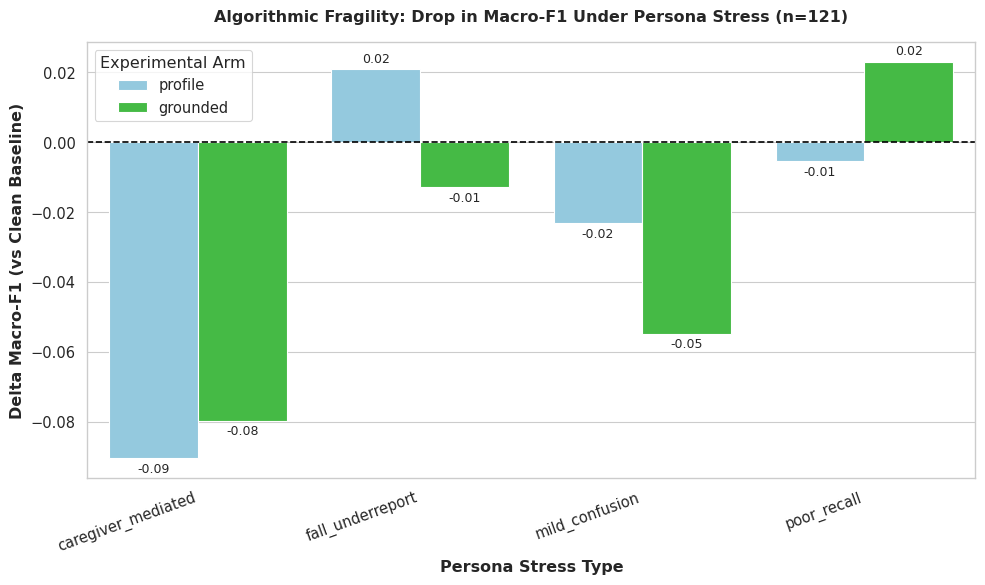

In [39]:
# =========================================================
# 25. Plot generation
# =========================================================
# SCIENTIFIC RATIONALE:
# Visual evidence is critical for communicating the study's core claims:
# 1. The performance gap between classical baselines and LLMs.
# 2. Algorithmic Fragility: Visualizing the negative performance deltas under stress.
# 3. Mitigation: Comparing the fragility of ungrounded vs. grounded arms directly.
# Using high-contrast, accessible color palettes and grouped charts improves readability.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

# Set plot style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

def save_enhanced_bar_plot(metric_dict, title, out_path, ylabel, palette="viridis"):
    names = list(metric_dict.keys())
    vals = list(metric_dict.values())

    # Recommendation: Save source data behind each figure for scientific hygiene
    source_df = pd.DataFrame({"arm": names, ylabel.lower(): vals})
    source_df.to_csv(out_path.replace(".png", "_source.csv"), index=False)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=names, y=vals, palette=palette)
    plt.title(title, fontweight="bold")
    plt.ylabel(ylabel, fontweight="bold")
    plt.xticks(rotation=30, ha="right")

    # Recommendation: Use robust bar labeling instead of brittle offset text
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

if RUN_LLM_EXPERIMENTS:
    # Recommendation: Guard check to ensure same evaluation population for all compared arms
    core_ns = {
        "Baseline (Majority)": baseline_metrics["majority"]["n"],
        "Baseline (TF-IDF LR)": baseline_metrics["tfidf_lr"]["n"],
        "LLM Raw": all_metrics["llm"]["llm_raw"]["n"],
        "LLM Profile": all_metrics["llm"]["llm_profile"]["n"],
        "LLM Grounded": all_metrics["llm"]["llm_grounded"]["n"],
    }

    # --- FIX: Issue 5 - Restore hard assertion to catch stale cache or population mismatch ---
    assert len(set(core_ns.values())) == 1, f"Data leakage or mismatch detected in evaluation N sizes: {core_ns}"
    n_eval = core_ns["LLM Grounded"]

    # Recommendation: Consistent color mapping across figures
    # Gray for baselines, Red for raw, Blue for profile, Green for grounded
    core_palette = ["#d3d3d3", "#a9a9a9", "#ff9999", "#87ceeb", "#32cd32"]

    # 1. Accuracy Plot
    acc_dict = {
        "Baseline (Majority)": baseline_metrics["majority"]["accuracy"],
        "Baseline (TF-IDF LR)": baseline_metrics["tfidf_lr"]["accuracy"],
        "LLM Raw": all_metrics["llm"]["llm_raw"]["accuracy"],
        "LLM Profile": all_metrics["llm"]["llm_profile"]["accuracy"],
        "LLM Grounded": all_metrics["llm"]["llm_grounded"]["accuracy"],
    }
    # Note: Abstention intentionally removed from here to prevent misleading comparisons.

    save_enhanced_bar_plot(
        acc_dict,
        f"Accuracy Across Core Arms (LLM n={n_eval})",
        f"{PLOTS_DIR}/accuracy_core_arms.png",
        "Accuracy",
        palette=core_palette
    )

    # 2. Macro-F1 Plot
    f1_dict = {
        "Baseline (Majority)": baseline_metrics["majority"]["macro_f1"],
        "Baseline (TF-IDF LR)": baseline_metrics["tfidf_lr"]["macro_f1"],
        "LLM Raw": all_metrics["llm"]["llm_raw"]["macro_f1"],
        "LLM Profile": all_metrics["llm"]["llm_profile"]["macro_f1"],
        "LLM Grounded": all_metrics["llm"]["llm_grounded"]["macro_f1"],
    }
    # Note: Abstention intentionally removed from here to prevent misleading comparisons.

    save_enhanced_bar_plot(
        f1_dict,
        f"Macro-F1 Across Core Arms (LLM n={n_eval})",
        f"{PLOTS_DIR}/macro_f1_core_arms.png",
        "Macro-F1",
        palette=core_palette
    )

# 3. Comparative Degradation Plot (Key Results Figure)
if RUN_PERSONA_STRESS_TEST and Path(f"{METRICS_DIR}/persona_degradation.csv").exists():
    degradation_df = pd.read_csv(f"{METRICS_DIR}/persona_degradation.csv")

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=degradation_df,
        x="persona_type",
        y="delta_macro_f1",
        hue="arm",
        # Enforce consistent colors matching the core palette: Profile=Blue, Grounded=Green
        palette={"profile": "#87ceeb", "grounded": "#32cd32"}
    )

    # Ensure 'n' is also passed here if it exists in scope, otherwise fallback to generic
    n_label = f" (n={n_eval})" if 'n_eval' in locals() else ""
    plt.title(f"Algorithmic Fragility: Drop in Macro-F1 Under Persona Stress{n_label}", fontweight="bold", pad=15)
    plt.ylabel("Delta Macro-F1 (vs Clean Baseline)", fontweight="bold")
    plt.xlabel("Persona Stress Type", fontweight="bold")
    plt.axhline(0, color='black', linewidth=1.2, linestyle='--') # 0 reference line
    plt.xticks(rotation=20, ha="right")
    plt.legend(title="Experimental Arm")

    # Use robust bar labeling
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/comparative_persona_degradation.png", dpi=300, bbox_inches='tight')
    plt.show()


## Section 21 — Reproducibility Manifest

In [40]:
# =========================================================
# 26. Reproducibility manifest and file inventory
# =========================================================
# SCIENTIFIC RATIONALE (Reproducibility):
# Many peer-reviewed venues evaluate computational artifacts for reproducibility.
# This block automatically compiles an "Artifact Manifest" capturing all experimental
# settings, hyper-parameters, and runtime details to aid in artifact evaluation processes.

import datetime
import platform

manifest = {
    "project_title": PROJECT_TITLE,
    "project_version": PROJECT_VERSION,
    "execution_timestamp_utc": datetime.datetime.utcnow().isoformat(),
    "python_version": platform.python_version(),
    "random_seed": RANDOM_SEED,
    "extcds_cases_path": EXTCDS_CASES_PATH,
    "use_bigquery_enrichment": USE_BIGQUERY_ENRICHMENT,
    "run_llm_experiments": RUN_LLM_EXPERIMENTS,
    "run_abstention_arm": RUN_ABSTENTION_ARM,
    "run_persona_stress_test": RUN_PERSONA_STRESS_TEST,
    "top_labels": top_labels,
    "label_space": label_space,
    "local_model_name": LOCAL_MODEL_NAME,
    "embedding_model_name": EMBEDDING_MODEL_NAME,
    "persona_types": PERSONA_TYPES,
    "llm_sample_size": LLM_SAMPLE_SIZE,
}

with open(f"{CONFIG_DIR}/manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

all_files = []
for root, _, files in os.walk(PROJECT_ROOT):
    for file in files:
        all_files.append(os.path.join(root, file))

inventory_df = pd.DataFrame({"file_path": sorted(all_files)})
inventory_df.to_csv(f"{CONFIG_DIR}/file_inventory.csv", index=False)

print(f"Manifest saved at: {CONFIG_DIR}/manifest.json")
print(f"Total tracked artifacts: {len(inventory_df)}")
display(inventory_df.tail(20))

Manifest saved at: /content/drive/MyDrive/msai_high_risk_project/configs/manifest.json
Total tracked artifacts: 95


,file_path
75,/content/drive/MyDrive/msai_high_risk_project/...
76,/content/drive/MyDrive/msai_high_risk_project/...
77,/content/drive/MyDrive/msai_high_risk_project/...
78,/content/drive/MyDrive/msai_high_risk_project/...
79,/content/drive/MyDrive/msai_high_risk_project/...
80,/content/drive/MyDrive/msai_high_risk_project/...
81,/content/drive/MyDrive/msai_high_risk_project/...
82,/content/drive/MyDrive/msai_high_risk_project/...
83,/content/drive/MyDrive/msai_high_risk_project/...
84,/content/drive/MyDrive/msai_high_risk_project/...


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## Section 22 — LaTeX Table Export

This final section generates paper-ready LaTeX tables. It separates the results into distinct tables for clean-condition performance and communication-stress degradation, avoiding mixing them.

In [41]:
# =========================================================
# 27. Generate LaTeX Table
# =========================================================
# SCIENTIFIC RATIONALE (Results Reporting):
# Automated table generation directly from cached artifacts prevents manual
# transcription errors. Following reviewer feedback, we separate the results
# into distinct tables: Clean-condition performance and Communication-stress.

import json
import pandas as pd
from pathlib import Path

def generate_latex_tables():
    # Fallback path in case earlier cells haven't been run in this session
    try:
        metrics_dir = METRICS_DIR
    except NameError:
        metrics_dir = "/content/drive/MyDrive/msai_high_risk_project/metrics"

    core_path = f"{metrics_dir}/metrics_summary_core.json"
    if not Path(core_path).exists():
        print("Metrics not found. Please run the evaluation sections first.")
        return

    with open(core_path, "r") as f:
        core_metrics = json.load(f)

    # TABLE 1: Clean-Condition Performance
    rows_clean = []
    for model, metrics in core_metrics.get("baselines", {}).items():
        top3 = metrics.get("top3_recall", float('nan'))
        rows_clean.append({
            "Model": f"Baseline: {model}",
            "Accuracy": metrics.get("accuracy", 0),
            "Macro-F1": metrics.get("macro_f1", 0),
            "Top-3 Recall": top3,
            "Cit. Validity": "-"
        })

    for model, metrics in core_metrics.get("llm", {}).items():
        rows_clean.append({
            "Model": model.replace("llm_", "LLM ").title(),
            "Accuracy": metrics.get("accuracy", 0),
            "Macro-F1": metrics.get("macro_f1", 0),
            "Top-3 Recall": metrics.get("top3_recall", float('nan')),
            "Cit. Validity": f"{metrics.get('citation_id_validity', float('nan')):.3f}" if 'citation_id_validity' in metrics else "-"
        })

    df_clean = pd.DataFrame(rows_clean)

    latex_clean = "\\begin{table}[htbp]\n\\centering\n\\caption{Clean-Condition Model Performance}\n\\label{tab:clean_results}\n\\begin{tabular}{lcccc}\n\\toprule\n"
    latex_clean += "Model & Accuracy & Macro-F1 & Top-3 Recall & Cit. Validity \\\\ \n\\midrule\n"
    for _, row in df_clean.iterrows():
        top3_val = f"{row['Top-3 Recall']:.3f}" if pd.notna(row['Top-3 Recall']) else "-"
        latex_clean += f"{row['Model']} & {row['Accuracy']:.3f} & {row['Macro-F1']:.3f} & {top3_val} & {row['Cit. Validity']} \\\\ \n"
    latex_clean += "\\bottomrule\n\\end{tabular}\n\\end{table}\n"

    print("=== Table 1: Clean-Condition Performance ===\n")
    print(latex_clean)
    display(df_clean)

    # TABLE 2: Communication-Stress Degradation
    persona_path = f"{metrics_dir}/metrics_summary_persona.json"
    if Path(persona_path).exists():
        rows_stress = []
        with open(persona_path, "r") as f:
            persona_metrics = json.load(f)
            for key, metrics in persona_metrics.items():
                arm, persona = key.split("__")
                rows_stress.append({
                    "Model": f"LLM {arm.title()}",
                    "Stress Condition": persona.replace("_", " ").title(),
                    "Accuracy": metrics.get("accuracy", 0),
                    "Macro-F1": metrics.get("macro_f1", 0),
                    "Top-3 Recall": metrics.get("top3_recall", float('nan')),
                    "Cit. Validity": f"{metrics.get('citation_id_validity', float('nan')):.3f}" if 'citation_id_validity' in metrics else "-"
                })

        df_stress = pd.DataFrame(rows_stress)

        latex_stress = "\\begin{table}[htbp]\n\\centering\n\\caption{Communication-Stress Degradation Performance}\n\\label{tab:stress_results}\n\\begin{tabular}{llcccc}\n\\toprule\n"
        latex_stress += "Model & Stress Condition & Accuracy & Macro-F1 & Top-3 Recall & Cit. Validity \\\\ \n\\midrule\n"
        for _, row in df_stress.iterrows():
            top3_val = f"{row['Top-3 Recall']:.3f}" if pd.notna(row['Top-3 Recall']) else "-"
            latex_stress += f"{row['Model']} & {row['Stress Condition']} & {row['Accuracy']:.3f} & {row['Macro-F1']:.3f} & {top3_val} & {row['Cit. Validity']} \\\\ \n"
        latex_stress += "\\bottomrule\n\\end{tabular}\n\\end{table}\n"

        print("\n=== Table 2: Communication-Stress Degradation ===\n")
        print(latex_stress)
        display(df_stress)

    print("\nNote: For the Cohort Characteristics table, please refer to the Cohort Summary blocks generated earlier (Section 10b).")

generate_latex_tables()

=== Table 1: Clean-Condition Performance ===

\begin{table}[htbp]
\centering
\caption{Clean-Condition Model Performance}
\label{tab:clean_results}
\begin{tabular}{lcccc}
\toprule
Model & Accuracy & Macro-F1 & Top-3 Recall & Cit. Validity \\ 
\midrule
Baseline: majority & 0.264 & 0.046 & - & - \\ 
Baseline: tfidf_lr & 0.645 & 0.588 & 0.884 & - \\ 
Llm Raw & 0.463 & 0.346 & 0.669 & - \\ 
Llm Profile & 0.397 & 0.257 & 0.595 & - \\ 
Llm Grounded & 0.364 & 0.279 & 0.612 & 1.000 \\ 
Llm Abstain & 0.298 & 0.151 & 0.570 & 1.000 \\ 
\bottomrule
\end{tabular}
\end{table}



,Model,Accuracy,Macro-F1,Top-3 Recall,Cit. Validity
0,Baseline: majority,0.264463,0.046478,NaN,-
1,Baseline: tfidf_lr,0.644628,0.588397,0.884298,-
2,Llm Raw,0.462810,0.346430,0.669421,-
3,Llm Profile,0.396694,0.257349,0.595041,-
4,Llm Grounded,0.363636,0.279086,0.611570,1.000
5,Llm Abstain,0.297521,0.150554,0.570248,1.000



=== Table 2: Communication-Stress Degradation ===

\begin{table}[htbp]
\centering
\caption{Communication-Stress Degradation Performance}
\label{tab:stress_results}
\begin{tabular}{llcccc}
\toprule
Model & Stress Condition & Accuracy & Macro-F1 & Top-3 Recall & Cit. Validity \\ 
\midrule
LLM Profile & Caregiver Mediated & 0.256 & 0.167 & 0.479 & - \\ 
LLM Profile & Fall Underreport & 0.405 & 0.278 & 0.595 & - \\ 
LLM Profile & Mild Confusion & 0.355 & 0.234 & 0.570 & - \\ 
LLM Profile & Poor Recall & 0.380 & 0.252 & 0.579 & - \\ 
LLM Grounded & Caregiver Mediated & 0.306 & 0.199 & 0.388 & 1.000 \\ 
LLM Grounded & Fall Underreport & 0.339 & 0.266 & 0.554 & 1.000 \\ 
LLM Grounded & Mild Confusion & 0.339 & 0.224 & 0.554 & 1.000 \\ 
LLM Grounded & Poor Recall & 0.397 & 0.302 & 0.612 & 1.000 \\ 
\bottomrule
\end{tabular}
\end{table}



,Model,Stress Condition,Accuracy,Macro-F1,Top-3 Recall,Cit. Validity
0,LLM Profile,Caregiver Mediated,0.256198,0.167054,0.479339,-
1,LLM Profile,Fall Underreport,0.404959,0.278177,0.595041,-
2,LLM Profile,Mild Confusion,0.355372,0.234228,0.570248,-
3,LLM Profile,Poor Recall,0.380165,0.251975,0.578512,-
4,LLM Grounded,Caregiver Mediated,0.305785,0.199470,0.388430,1.000
5,LLM Grounded,Fall Underreport,0.338843,0.266272,0.553719,1.000
6,LLM Grounded,Mild Confusion,0.338843,0.224284,0.553719,1.000
7,LLM Grounded,Poor Recall,0.396694,0.301932,0.611570,1.000



Note: For the Cohort Characteristics table, please refer to the Cohort Summary blocks generated earlier (Section 10b).


## Section 24 — Final Notes

### Main scientific contribution
This notebook provides an audit-style evaluation framework for older-adult intake-stage specialist referral prediction. It combines baseline-controlled clinical NLP evaluation, local LLM prompting, within-case evidence attribution, model-sensitivity analysis, abstention testing, and deterministic communication stress testing.

### Main interpretation
The central finding is not that local LLMs outperform classical baselines. Instead, TF-IDF logistic regression remains the strongest clean-condition classifier. The local LLM workflows are useful for studying structured output behavior, citation traceability, model sensitivity, and communication-stress fragility.

### Responsible interpretation of evidence attribution
Within-case evidence attribution improves citation traceability but does not prove clinical evidence support or rationale faithfulness. Citation-ID validity should be interpreted as an audit signal, not as evidence of clinical correctness.

### Responsible interpretation of communication stress testing
Caregiver-mediated communication produced the largest degradation in the primary Qwen2.5-1.5B stress-test workflow. This finding motivates future research on longitudinal, structured, interoperable health-data platforms, but it does not prove that such platforms will solve referral-support fragility.